In [1]:
import pandas as pd
import yaml
import os
import openpyxl
import pygwalker as pyg
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import re
import sys
from datetime import datetime
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

In [2]:
# To add project files
# Keeps going up project structure until it gets to the root.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a5ff07-91e0-8329-88d1-cf2ea6c159c2
project_root = Path().resolve()
while project_root.name != "AFOLU_GHG_flux_model":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.utilities import constants_and_names as cn
from src.utilities import universal_utilities as uu

now = datetime.now()
today = now.strftime("%Y%m%d")

pd.set_option('display.max_columns', None)

In [3]:
# Assigns climate domain column
def assign_climate_domain(df):

    cont_eco = df["continent_ecozone"]

    df["climate_domain"] = np.select(
        [
            cont_eco.str.contains("boreal", case=False, na=False) | cont_eco.str.contains("polar", case=False, na=False),
            cont_eco.str.contains("temperate", case=False, na=False),
            cont_eco.str.contains("tropical", case=False, na=False) | cont_eco.str.contains("subtropical", case=False, na=False),
        ],
        [
            "Boreal",
            "Temperate",
            "Subtropical/tropical",
        ],
        default="Other"
    )

    return df

In [4]:
# Fills in the intervening years of the multi-year intervals for soil data.
# Basically, duplicates values from end-of-interval years for all the preceding years in the interval,
# but only for that row's own nominal interval. Missing intervals stay blank.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c2fe30-7004-8328-9f6d-1c231ba04e20
def fill_in_soil_years(df, series_cols):

    # For summing within year
    group_cols = series_cols + ["year"]

    # Aggregate first
    df = (
        df
        .groupby(group_cols, dropna=False, as_index=False)
        .agg({
            "flux_Mg_CO2e_yr": "sum",
            "area_ha": "sum"
        })
    )

    # Sort by timeseries + year
    df = df.sort_values(series_cols + ["year"]).reset_index(drop=True)

    year_vals = df["year"].astype(int)

    # Maximum (final) year in the dataset
    last_year = year_vals.max()

    # Nominal interval length for each endpoint year:
    # - years divisible by 5 -> 5-year interval
    # - final year in dataset -> interval from 2021 to last_year
    # - everything else defaults to 1 year unless you add more rules
    interval_len = np.where(
        year_vals.eq(last_year),
        last_year - 2021 + 1,
        np.where(year_vals.mod(5).eq(0), 5, 1)
    )

    # Start year comes only from the row's own nominal interval,
    # not from the previous observed year.
    start_year = (year_vals - interval_len + 1).astype(int).to_numpy()
    end_year = year_vals.to_numpy()

    # Number of repetitions for each interval
    n_rep = end_year - start_year + 1

    # Duplicate rows
    expanded = df.loc[df.index.repeat(n_rep)].copy()

    # Assign correct years
    expanded["year"] = np.concatenate([
        np.arange(s, e + 1) for s, e in zip(start_year, end_year)
    ])

    expanded = expanded.reset_index(drop=True)

    # If the source data ends before the end of the vegetation timeseries, extendyears through 2024 to match vegetation timeseries
    if last_year < cn.years_annual[-1]:
        rows_2022 = expanded[expanded["year"] == 2022].copy()

        rows_2023 = rows_2022.copy()
        rows_2023["year"] = 2023

        rows_2024 = rows_2022.copy()
        rows_2024["year"] = 2024

        expanded = pd.concat([expanded, rows_2023, rows_2024], ignore_index=True)
        expanded = expanded.sort_values(series_cols + ["year"]).reset_index(drop=True)

    return expanded

In [5]:
# Converts long-format df to wide-format df
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69fe3161-edb8-832e-a90d-d9e75e4012d3
def create_wide_df(combined_df, value_field):

    print(f"Converting combined table from long to wide: {uu.timestr()}")

    # Columns to use and to not use as contextual layers. Drops gas because it's implicit in analysis_layer.
    id_cols = [
        c for c in combined_df.columns
        if c not in ["analysis_layer", value_field, "density__Mg_ha", "area_ha", "gas", "LULUCF_component"]
    ]

    # Reshapes from long to wide, with value and area_ha for each analysis_layer.
    # ChatGPT says this is safer for giant tables than using pivot_table
    print(f"  Grouping and summing: {uu.timestr()}")
    wide = (
        combined_df
        .groupby(id_cols + ["analysis_layer"], observed=True, sort=False, dropna=False)[[value_field]]
        # .groupby(id_cols + ["analysis_layer"], observed=True, sort=False)[[value_field, "area_ha"]]
        .sum()
        .unstack("analysis_layer")
        .fillna(0)
    )

    # Appends __value or __area_ha to each analysis layer
    print(f"  Cleaning columns: {uu.timestr()}")
    wide.columns = [
        f"{analysis_layer}__value"
        for _, analysis_layer in wide.columns
    ]
    wide = wide.reset_index()

    # Reorders columns so that __value fields are before __area_ha fields
    value_cols = sorted([c for c in wide.columns if c.endswith("__value")])
    wide = wide[id_cols + value_cols]
    # area_cols = sorted([c for c in wide.columns if c.endswith("__area_ha")])
    # wide = wide[id_cols + value_cols + area_cols]
    combined_wide_df = wide.reset_index(drop=True)


    print(f"  Making summative soil columns: {uu.timestr()}")

    # Sum all soil columns. This has to come before the organic soil summation. 
    soil_cols = [c for c in combined_wide_df.columns if "soil" in c]
    
    combined_wide_df["soil__all_gases__MgCO2e__value"] = (
        combined_wide_df[soil_cols]
        .sum(axis=1)
    )
    
    # Sum all organic soil columns
    organic_cols = [c for c in combined_wide_df.columns if "organic" in c]
    
    combined_wide_df["organic_soil__all_gases__MgCO2e__value"] = (
        combined_wide_df[organic_cols]
        .sum(axis=1)
    )

    return combined_wide_df

In [6]:
# Context columns that define a unique timeseries. Does not include year.
series_cols = [
    "analysis_layer",
    "adm0", "country_name", "region",
    "land_state_node", "land_state", "land_state_meaning",
    "WDPA", "WDPA_type",
    "cont_eco", "continent", "continent_ecozone", "climate_domain",
    "Landmark",
    "starting_composite_primary_forest",
    "tile_id",
    "land_state_broad_class",
    "land_state_detailed_class",
    "WDPA_high_protection",
    "tall_veg_type",
    "LULUCF_component"
]

# Contextual columns for grouping in export csvs. Includes year.
export_csv_group_cols = [
    "analysis_layer",
    "adm0", "country_name", "region",
    # "land_state_node", "land_state", "land_state_meaning",
    # "WDPA", "WDPA_type",
    "cont_eco", "continent", "continent_ecozone", "climate_domain",
    # "Landmark",
    # "starting_composite_primary_forest",
    "year",
    # "tile_id",
    "land_state_broad_class",
    "land_state_detailed_class",
    # "WDPA_high_protection",
    "tall_veg_type",
    "LULUCF_component"
]

### Input table paths

In [7]:
# Vegetation zonal stats output
veg_zonal_stats_folder = f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/vegetation_v{cn.veg_model_version_underscore}_standard_global__full_run__20260224/'
veg_parquet_name = f'veg_model_zonal_stats_v{cn.veg_model_version_underscore}_20260224_19_21_07.parquet'

In [8]:
# SOC (including mineral soil) zonal stats output
SOC_zonal_stats_folder = f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/SOC_v{cn.SOC_model_version_underscore}_standard_global__20260323/'
SOC_parquet_name = f'SOC_zonal_stats_v{cn.SOC_model_version_underscore}_20260323_15_05_52.parquet'

In [9]:
# Organic soil zonal stats output
org_soil_zonal_stats_folder = f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/organic_soil_v{cn.organic_soil_model_version_underscore}_standard_global__20260512/'
# Erin's v1.0.0 run only has the 2024 interval, but I need the preceding interval as well, so I just copied the final interval into the 2016-2020 period
org_soil_csv_name = 'stats_for_lulucf_paper__from_Erin_Glen_via_Slack_20260512__final_period_copied_back.csv'  

In [10]:
# LULUCF outputs
LULUCF_zonal_stats_folder = Path(f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF__veg_v{cn.veg_model_version_underscore}__minsoil_v{cn.SOC_model_version_underscore}__orgsoil_v{cn.organic_soil_model_version_underscore}/')
LULUCF_zonal_stats_folder.mkdir(parents=True, exist_ok=True)
LULUCF_zonal_stats_folder

PosixPath('/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF__veg_v1_0_5__minsoil_v1_0_0__orgsoil_v1_0_0')

### Full dataframes with basic standardization of organic soil and SOC density to vegetation df

In [11]:
%%time

# Reads vegetation zonal stats parquet table
veg_df_raw = pd.read_parquet(f'{veg_zonal_stats_folder}{veg_parquet_name}')

# Renames value column with units
veg_df_raw.rename(columns={'value': 'flux_Mg_CO2e_yr'}, inplace=True)

# Renames some countries with long names
veg_df_raw["country_name"] = veg_df_raw["country_name"].replace({         
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Russian Federation": "Russia",
    "Democratic Republic of the Congo": "DR Congo",
    "United States of America (the)": "USA"
})

# Create new column that separates out high protection status
# https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69aee45e-ce6c-8325-b1d0-a6c6b0e7ae2e
veg_df_raw["WDPA_high_protection"] = "Other protection status"
veg_df_raw.loc[veg_df_raw["WDPA_type"] == "NA", "WDPA_high_protection"] = "Not protected"
veg_df_raw.loc[veg_df_raw["WDPA_type"].isin(["Cateogry Ia", "Category Ib", "Category II", "Category III"]), "WDPA_high_protection"] = "High protection"

# Assigns tall vegetation type
state_node_df = pd.read_excel(cn.state_node_lookup_table_local, sheet_name=cn.sheet)
veg_df_raw = veg_df_raw.merge(state_node_df[['land_state', 'tall_veg_type']],  # Merge tall_veg_type field from state_node_df
          left_on='land_state_node', right_on='land_state',
          how='left')

# Adds climate domain column
veg_df_raw = assign_climate_domain(veg_df_raw)

# Prepends veg to rows to clarify their scope
veg_df_raw["analysis_layer"] = "veg_" + veg_df_raw["analysis_layer"]

# Because some contextual rows are blank
# Shouldn't be necessary if I run vegetation zonal stats again and create new parquet files 
veg_df_raw["continent_ecozone"] = veg_df_raw["continent_ecozone"].fillna("Unassigned")  
veg_df_raw["country_name"] = veg_df_raw["country_name"].fillna("Unassigned")  
veg_df_raw['region'] = veg_df_raw['region'].fillna("Unassigned")

# Corrected classification of trees remaining trees with fire as tree_tree_disturbed_fire_only. 
# In the zonal stats run, I classified those as tree_tree_undisturbed, which is causing confusion with stats down the line.
mask = (
    (veg_df_raw["land_state_detailed_class"] == "tree_tree_undisturbed") &
    (veg_df_raw["land_state_meaning"].str.endswith("with fire", na=False))
)

veg_df_raw.loc[mask, "land_state_detailed_class"] = "tree_tree_disturbed_fire_only"

# New column to specify this is vegetation, as opposed to organic or mineral soil (for combined LULUCF table)
veg_df_raw["LULUCF_component"] = "vegetation"

print(f"Rows in df: {len(veg_df_raw)}")
veg_df_raw.head(6)

Rows in df: 27999047
CPU times: user 1min 8s, sys: 17.8 s, total: 1min 26s
Wall time: 1min 13s


,analysis_layer,adm0,land_state_node,WDPA,cont_eco,Landmark,starting_composite_primary_forest,year,flux_Mg_CO2e_yr,tile_id,area_ha,land_state_meaning,land_state_broad_class,land_state_detailed_class,country_name,region,continent,continent_ecozone,WDPA_type,density__Mg_ha,WDPA_high_protection,land_state,tall_veg_type,climate_domain,LULUCF_component
0,veg_gross_emissions__AGC__MgCO2,NA,12100000,0,1020,0,0,2016,8.630256,00N_000E,1.230781,Temporary loss of mangroves,tree,tree_loss,no_country,no_country,Africa,Tropical rainforest,NA,7.012017,Not protected,12100000,mangrove,Subtropical/tropical,vegetation
1,veg_gross_emissions__AGC__MgCO2,NA,12100000,0,1020,0,0,2017,12.399805,00N_000E,0.230765,Temporary loss of mangroves,tree,tree_loss,no_country,no_country,Africa,Tropical rainforest,NA,53.733429,Not protected,12100000,mangrove,Subtropical/tropical,vegetation
2,veg_gross_emissions__AGC__MgCO2,NA,12100000,0,1020,0,1,2016,58.504814,00N_000E,1.923030,Temporary loss of mangroves,tree,tree_loss,no_country,no_country,Africa,Tropical rainforest,NA,30.423250,Not protected,12100000,mangrove,Subtropical/tropical,vegetation
3,veg_gross_emissions__AGC__MgCO2,NA,12100000,0,1020,0,1,2017,16.906231,00N_000E,0.615387,Temporary loss of mangroves,tree,tree_loss,no_country,no_country,Africa,Tropical rainforest,NA,27.472500,Not protected,12100000,mangrove,Subtropical/tropical,vegetation
4,veg_gross_emissions__AGC__MgCO2,NA,12100000,11,1020,0,0,2016,1.523145,00N_000E,1.538519,Temporary loss of mangroves,tree,tree_loss,no_country,no_country,Africa,Tropical rainforest,Not Reported,0.990007,Other protection status,12100000,mangrove,Subtropical/tropical,vegetation
5,veg_gross_emissions__AGC__MgCO2,NA,12100000,11,1020,0,0,2017,6.321051,00N_000E,0.153853,Temporary loss of mangroves,tree,tree_loss,no_country,no_country,Africa,Tropical rainforest,Not Reported,41.084923,Other protection status,12100000,mangrove,Subtropical/tropical,vegetation


In [12]:
%%time

# Reads SOC zonal stats parquet table
SOC_df_raw = pd.read_parquet(f'{SOC_zonal_stats_folder}{SOC_parquet_name}')

# Renames value column with units
SOC_df_raw.rename(columns={'value': 'flux_Mg_CO2e_yr'}, inplace=True)

# Renames some countries with long names
SOC_df_raw["country_name"] = SOC_df_raw["country_name"].replace({         
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Russian Federation": "Russia",
    "Democratic Republic of the Congo": "DR Congo",
    "United States of America (the)": "USA"
})

# Identifies change layers only to do some unit conversions
mask = SOC_df_raw["analysis_layer"].str.contains("change", na=False)

# Changes units in analysis_layer field to MgCO2 for change layers
SOC_df_raw.loc[mask, "analysis_layer"] = SOC_df_raw["analysis_layer"].str.replace("MgC", "MgCO2", regex=False)

# For change layers, actually changes units from Mg C/yr to Mg CO2/yr, then switches sign to negative for gain and positive for loss (to match vegetation)
SOC_df_raw.loc[mask, "flux_Mg_CO2e_yr"] *= cn.C_to_CO2
SOC_df_raw.loc[mask, "flux_Mg_CO2e_yr"] *= -1

# Create new column that separates out high protection status
# https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69aee45e-ce6c-8325-b1d0-a6c6b0e7ae2e
SOC_df_raw["WDPA_high_protection"] = "Other protection status"
SOC_df_raw.loc[SOC_df_raw["WDPA_type"] == "NA", "WDPA_high_protection"] = "Not protected"
SOC_df_raw.loc[SOC_df_raw["WDPA_type"].isin(["Cateogry Ia", "Category Ib", "Category II", "Category III"]), "WDPA_high_protection"] = "High protection"

# Adds climate domain column
SOC_df_raw = assign_climate_domain(SOC_df_raw)

# Adds columns to SOC that are in the vegetation table so the tables can be combined
# https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c2fe30-7004-8328-9f6d-1c231ba04e20
target_cols = list(veg_df_raw.columns) + [
    c for c in SOC_df_raw.columns if c not in veg_df_raw.columns
]
SOC_df_aligned = SOC_df_raw.reindex(columns=target_cols)

# Drops some contextual layers from SOC that I didn't use for vegetation. This finalizes the equivalency of the columns in the vegetation and SOC tables.
SOC_df_aligned = SOC_df_aligned.drop(columns=['KBA', 'watershed', 'watershed_name'])
print("veg_df_graphs:", veg_df_raw.columns)
print("SOC_df_aligned:", SOC_df_aligned.columns)

# Aggregates by unique combinations of remaining contextual layers. Necessary because SOC-only contextual layers like KBA were dropped above, so some rows will not be unique contextual combinations anymore. 
SOC_df_aligned = (
    SOC_df_aligned
    .groupby(series_cols + ["year"], dropna=False, as_index=False)
    .agg({
        "flux_Mg_CO2e_yr": "sum",
        "area_ha": "sum"
    })
)

# New column to specify this is mineral soil, as opposed to vegetation or organic soil (for combined LULUCF table).
SOC_df_aligned["LULUCF_component"] = "mineral_soil"

print(f"Rows in SOC_df_aligned: {len(SOC_df_aligned)}")
# SOC_df_aligned.to_csv("/mnt/c/GIS/SOC_aligned.csv", index=False)


### Fills in the years for multi-year interval SOC data.
# 2010 is copied to 2006-2010, 2015 to 2011-2015, 2020 to 2016-2020, and 2022 to 2021-2024 (to match end of vegetation timeseries). 
# If a year doesn't have data for a given year and combination of contextual layers, there is nothing to expand and all years in that interval are empty. 
SOC_df_years_filled_in = fill_in_soil_years(SOC_df_aligned, series_cols)
print(f"Rows in SOC_df_years_filled_in: {len(SOC_df_years_filled_in)}")
# SOC_df_years_filled_in

# Should be very close to 4.75. If every contextual combination has every year, full year expansion would be 4.75 (2010, 2015 and 2020 intervals expanded 5x years, 2022 expanded 4x years).
# However, some contextual combinations don't have all years (usually because they're so rare and other years have just 1 pixel of that combination),
# so that doesn't get expanded to other years. This results in deviation from the 4.25x expansion. 
print(f"Ratio of rows in unexpanded to expanded tables: {len(SOC_df_years_filled_in)/len(SOC_df_aligned)}")

# Drops all years before vegetation data because we don't need those for LULUCF
SOC_df_years_filled_in_post_2016 = SOC_df_years_filled_in[SOC_df_years_filled_in["year"] >= cn.interval_end_years_annual[0]].reset_index(drop=True)

# SOC_df_years_filled_in_post_2016.to_csv("/mnt/c/GIS/SOC_years_filled_in_post_2016.csv", index=False)
SOC_df_years_filled_in_post_2016

SOC_year_count = len(SOC_df_years_filled_in_post_2016['year'].unique())
print(f"Years in SOC data: {SOC_year_count}")

# QC: Timeseries of SOC change (full and mineral extent) to compare against chunk stats (Mg C/yr)
layers = [
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2",
    "SOC_change__full_extent__0-30cm_MgCO2"
]
df_sum = (
    SOC_df_years_filled_in_post_2016[SOC_df_years_filled_in_post_2016["analysis_layer"].isin(layers)]
    .groupby(["analysis_layer", "year"], as_index=False)["flux_Mg_CO2e_yr"]
    .sum()
)
df_sum["flux_Gt_C_yr"] = df_sum["flux_Mg_CO2e_yr"] / 1e9 * 12/44  # Converts from Mg CO2/yr back to Mg C/yr because that's the chunk stats unit
print(df_sum)

SOC_df_years_filled_in_post_2016.head(6)

veg_df_graphs: Index(['analysis_layer', 'adm0', 'land_state_node', 'WDPA', 'cont_eco',
       'Landmark', 'starting_composite_primary_forest', 'year',
       'flux_Mg_CO2e_yr', 'tile_id', 'area_ha', 'land_state_meaning',
       'land_state_broad_class', 'land_state_detailed_class', 'country_name',
       'region', 'continent', 'continent_ecozone', 'WDPA_type',
       'density__Mg_ha', 'WDPA_high_protection', 'land_state', 'tall_veg_type',
       'climate_domain', 'LULUCF_component'],
      dtype='object')
SOC_df_aligned: Index(['analysis_layer', 'adm0', 'land_state_node', 'WDPA', 'cont_eco',
       'Landmark', 'starting_composite_primary_forest', 'year',
       'flux_Mg_CO2e_yr', 'tile_id', 'area_ha', 'land_state_meaning',
       'land_state_broad_class', 'land_state_detailed_class', 'country_name',
       'region', 'continent', 'continent_ecozone', 'WDPA_type',
       'density__Mg_ha', 'WDPA_high_protection', 'land_state', 'tall_veg_type',
       'climate_domain', 'LULUCF_component'],

,analysis_layer,adm0,country_name,region,land_state_node,land_state,land_state_meaning,WDPA,WDPA_type,cont_eco,continent,continent_ecozone,climate_domain,Landmark,starting_composite_primary_forest,tile_id,land_state_broad_class,land_state_detailed_class,WDPA_high_protection,tall_veg_type,LULUCF_component,year,flux_Mg_CO2e_yr,area_ha
0,SOC_change__full_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,NaN,NaN,NaN,0,NA,2021,America South,Tropical shrubland,Subtropical/tropical,0,0,20N_070W,NaN,NaN,Not protected,NaN,mineral_soil,2016,-225.981735,8303.546875
1,SOC_change__full_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,NaN,NaN,NaN,0,NA,2021,America South,Tropical shrubland,Subtropical/tropical,0,0,20N_070W,NaN,NaN,Not protected,NaN,mineral_soil,2017,-225.981735,8303.546875
2,SOC_change__full_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,NaN,NaN,NaN,0,NA,2021,America South,Tropical shrubland,Subtropical/tropical,0,0,20N_070W,NaN,NaN,Not protected,NaN,mineral_soil,2018,-225.981735,8303.546875
3,SOC_change__full_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,NaN,NaN,NaN,0,NA,2021,America South,Tropical shrubland,Subtropical/tropical,0,0,20N_070W,NaN,NaN,Not protected,NaN,mineral_soil,2019,-225.981735,8303.546875
4,SOC_change__full_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,NaN,NaN,NaN,0,NA,2021,America South,Tropical shrubland,Subtropical/tropical,0,0,20N_070W,NaN,NaN,Not protected,NaN,mineral_soil,2020,-225.981735,8303.546875
5,SOC_change__full_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,NaN,NaN,NaN,0,NA,2021,America South,Tropical shrubland,Subtropical/tropical,0,0,20N_070W,NaN,NaN,Not protected,NaN,mineral_soil,2021,2476.200195,8303.546875


In [13]:
# # Makes a minimal table of SOC density and change by country and interval 

# df = pd.read_parquet(f'{SOC_zonal_stats_folder}{SOC_parquet_name}')
# df
# df_sum = (
#     df
#     .groupby(["analysis_layer", "year", "adm0", "country_name"], as_index=False)["value"]
#     .sum()
# )
# df_sum.to_csv('/mnt/c/GIS/SOC_by_admin.csv', index=False)

In [14]:
%%time

# Reads organic soil zonal stats parquet table
org_soil_df_raw = pd.read_csv(f'{org_soil_zonal_stats_folder}{org_soil_csv_name}')

# Makes table columns generally match vegetation and SOC
org_soil_df_raw = org_soil_df_raw.drop(columns=['gadm_adm0'])
org_soil_df_raw.rename(columns={'country': 'country_name', 
                                'iso3': 'adm0', 
                                'emissions_MgCO2e': 'flux_Mg_CO2e_yr',   # Erin confirmed in Slack that the values are already Mg CO2e/yr
                                'component': 'analysis_layer',
                                'interval_end': 'year'},
                       inplace=True)

# Renames some countries with long names
org_soil_df_raw["country_name"] = org_soil_df_raw["country_name"].replace({         
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Russian Federation": "Russia",
    "Democratic Republic of the Congo": "DR Congo",
    "United States of America (the)": "USA"
})

org_soil_df_raw["climate_domain"] = org_soil_df_raw["climate_domain"].replace({         
    "tropical": "Subtropical/tropical",
    "temperate": "Temperate",
    "boreal": "Boreal",
    "Unspecified": "Other"
})

# Adds columns to organic soil that are in the vegetation table so the tables can be combined
# https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c2fe30-7004-8328-9f6d-1c231ba04e20
target_cols = list(veg_df_raw.columns) + [
    c for c in org_soil_df_raw.columns if c not in veg_df_raw.columns
]
org_soil_df_aligned = org_soil_df_raw.reindex(columns=target_cols)
print("veg_df_graphs:", veg_df_raw.columns)
print("org_soil_df_aligned:", org_soil_df_aligned.columns)

# Prepends org_soil to rows to clarify their scope
org_soil_df_aligned["analysis_layer"] = org_soil_df_aligned["analysis_layer"].str.lower()
org_soil_df_aligned["analysis_layer"] = "organic_soil_" + org_soil_df_aligned["analysis_layer"] + "__all_gases__MgCO2e"

# New column to specify this is mineral soil, as opposed to vegetation or organic soil (for combined LULUCF table)
org_soil_df_aligned["LULUCF_component"] = "organic_soil"

print(f"Rows in df: {len(org_soil_df_aligned)}")
# org_soil_df_aligned.to_csv("/mnt/c/GIS/org_soil_aligned.csv", index=False)


### Fills in the years for multi-year interval SOC data.
# 2010 is copied to 2006-2010, 2015 to 2011-2015, 2020 to 2016-2020, and 2024 to 2021-2024. 
# If a year doesn't have data for a given year and combination of contextual layers, there is nothing to expand and all years in that interval are empty. 
org_soil_df_years_filled_in = fill_in_soil_years(org_soil_df_aligned, series_cols)
# org_soil_df_years_filled_in.to_csv("/mnt/c/GIS/org_soil_years_filled_in.csv", index=False)
print(f"Rows in org_soil_df_years_filled_in: {len(org_soil_df_years_filled_in)}")

# Should be around 4.75. If every contextual combination has every year, full year expansion would be 4.75 (2010, 2015 and 2020 intervals expanded 5x years, 2022 expanded 4x years).
# However, some contextual combinations don't have all years (usually because they're so rare and other years have just 1 pixel of that combination),
# so that doesn't get expanded to other years. This results in deviation from the 4.75x expansion. 
print(f"Ratio of rows in unexpanded to expanded tables: {len(org_soil_df_years_filled_in)/len(org_soil_df_aligned)}")

# Number of years in organic soil data
org_soil_year_count = len(org_soil_df_years_filled_in['year'].unique())
print(f"Years of organic soil data: {org_soil_year_count}")

# Drops all years before vegetation data because we don't need those for LULUCF
org_soil_df_years_filled_in_post_2016 = org_soil_df_years_filled_in[org_soil_df_years_filled_in["year"] >= cn.interval_end_years_annual[0]].reset_index(drop=True)

org_soil_df_years_filled_in_post_2016.to_csv(f"{org_soil_zonal_stats_folder}org_soil_years_filled_in_post_2016_{today}.csv", index=False)
org_soil_df_years_filled_in_post_2016

veg_df_graphs: Index(['analysis_layer', 'adm0', 'land_state_node', 'WDPA', 'cont_eco',
       'Landmark', 'starting_composite_primary_forest', 'year',
       'flux_Mg_CO2e_yr', 'tile_id', 'area_ha', 'land_state_meaning',
       'land_state_broad_class', 'land_state_detailed_class', 'country_name',
       'region', 'continent', 'continent_ecozone', 'WDPA_type',
       'density__Mg_ha', 'WDPA_high_protection', 'land_state', 'tall_veg_type',
       'climate_domain', 'LULUCF_component'],
      dtype='object')
org_soil_df_aligned: Index(['analysis_layer', 'adm0', 'land_state_node', 'WDPA', 'cont_eco',
       'Landmark', 'starting_composite_primary_forest', 'year',
       'flux_Mg_CO2e_yr', 'tile_id', 'area_ha', 'land_state_meaning',
       'land_state_broad_class', 'land_state_detailed_class', 'country_name',
       'region', 'continent', 'continent_ecozone', 'WDPA_type',
       'density__Mg_ha', 'WDPA_high_protection', 'land_state', 'tall_veg_type',
       'climate_domain', 'LULUCF_compone

,analysis_layer,adm0,country_name,region,land_state_node,land_state,land_state_meaning,WDPA,WDPA_type,cont_eco,continent,continent_ecozone,climate_domain,Landmark,starting_composite_primary_forest,tile_id,land_state_broad_class,land_state_detailed_class,WDPA_high_protection,tall_veg_type,LULUCF_component,year,flux_Mg_CO2e_yr,area_ha
0,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Temperate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2016,17012.414750,584.875153
1,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Temperate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2017,17012.414750,584.875153
2,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Temperate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2018,17012.414750,584.875153
3,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Temperate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2019,17012.414750,584.875153
4,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Temperate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2020,17012.414750,584.875153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1696,organic_soil_fire__all_gases__MgCO2e,VEN,Venezuela,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Subtropical/tropical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2020,7442.018097,26713.008880
1697,organic_soil_fire__all_gases__MgCO2e,VEN,Venezuela,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Subtropical/tropical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2021,7442.018097,26713.008880
1698,organic_soil_fire__all_gases__MgCO2e,VEN,Venezuela,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Subtropical/tropical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2022,7442.018097,26713.008880
1699,organic_soil_fire__all_gases__MgCO2e,VEN,Venezuela,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Subtropical/tropical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,organic_soil,2023,7442.018097,26713.008880


In [15]:
%%time

# Create LULUCF dataframe with net LULUCF fluxes
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c6b94c-b5c0-8332-bd49-807275f66beb

LULUCF = pd.concat([veg_df_raw, SOC_df_years_filled_in_post_2016, org_soil_df_years_filled_in_post_2016], ignore_index=True)

# Drops area and density since organic soil table doesn't have either
LULUCF = LULUCF.drop(columns=['area_ha', 'density__Mg_ha'])

df = LULUCF.copy()

components_to_sum = [
    "veg_net_flux__all_C_pools__all_gases__MgCO2e",
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2",
    "organic_soil_drainage__all_gases__MgCO2e",
    "organic_soil_extraction__all_gases__MgCO2e",
    "organic_soil_fire__all_gases__MgCO2e",
]

# Keep rows with only the five flux components
df_components = df[df["analysis_layer"].isin(components_to_sum)].copy()

# Contextual columns to group by
# Exclude the layer name and the flux field being summed.
group_cols = [
    c for c in df_components.columns
    if c not in ["analysis_layer", "flux_Mg_CO2e_yr"]
]

# Sum flux across the five components for each unique context combination
df_lulucf_total = (
    df_components
    .groupby(group_cols, dropna=False, as_index=False)
    .agg({
        "flux_Mg_CO2e_yr": "sum"
    })
)

# Add the new layer name
df_lulucf_total["analysis_layer"] = "LULUCF_net_flux__MgCO2e"

# Set a LULUCF label for the component field
df_lulucf_total["LULUCF_component"] = "total_LULUCF"

# Reorder columns to match the existing LULUCF dataframe
df_lulucf_total = df_lulucf_total[df.columns]

# Append to bottom of original table
LULUCF = pd.concat([df, df_lulucf_total], ignore_index=True)
print(f"Rows in df: {len(LULUCF)}")
LULUCF.head()

Rows in df: 31942155
CPU times: user 21.9 s, sys: 17 s, total: 38.9 s
Wall time: 40 s


,analysis_layer,adm0,land_state_node,WDPA,cont_eco,Landmark,starting_composite_primary_forest,year,flux_Mg_CO2e_yr,tile_id,land_state_meaning,land_state_broad_class,land_state_detailed_class,country_name,region,continent,continent_ecozone,WDPA_type,WDPA_high_protection,land_state,tall_veg_type,climate_domain,LULUCF_component
0,veg_gross_emissions__AGC__MgCO2,NA,12100000.0,0.0,1020.0,0.0,0.0,2016,8.630256,00N_000E,Temporary loss of mangroves,tree,tree_loss,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,12100000.0,mangrove,Subtropical/tropical,vegetation
1,veg_gross_emissions__AGC__MgCO2,NA,12100000.0,0.0,1020.0,0.0,0.0,2017,12.399805,00N_000E,Temporary loss of mangroves,tree,tree_loss,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,12100000.0,mangrove,Subtropical/tropical,vegetation
2,veg_gross_emissions__AGC__MgCO2,NA,12100000.0,0.0,1020.0,0.0,1.0,2016,58.504814,00N_000E,Temporary loss of mangroves,tree,tree_loss,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,12100000.0,mangrove,Subtropical/tropical,vegetation
3,veg_gross_emissions__AGC__MgCO2,NA,12100000.0,0.0,1020.0,0.0,1.0,2017,16.906231,00N_000E,Temporary loss of mangroves,tree,tree_loss,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,12100000.0,mangrove,Subtropical/tropical,vegetation
4,veg_gross_emissions__AGC__MgCO2,NA,12100000.0,11.0,1020.0,0.0,0.0,2016,1.523145,00N_000E,Temporary loss of mangroves,tree,tree_loss,no_country,no_country,Africa,Tropical rainforest,Not Reported,Other protection status,12100000.0,mangrove,Subtropical/tropical,vegetation


### Dataframes with less necessary analysis layers removed

In [16]:
%%time
# Drops analysis layers from vegetation dataframe so it can be graphed more easily

veg_layers_to_drop = [
    f"veg_carbon_density__non_soil__MgC_ha",
    f"veg_{cn.agc_gross_emis_pattern}",
    f"veg_{cn.bgc_gross_emis_pattern}",
    f"veg_{cn.deadwood_c_gross_emis_pattern}",
    f"veg_{cn.litter_c_gross_emis_pattern}",
    f"veg_{cn.net_flux_all_C_pools_CO2_only_pattern}",
    f"veg_{cn.agc_gross_removals_pattern}",
    f"veg_{cn.bgc_gross_removals_pattern}",
    f"veg_{cn.deadwood_c_gross_removals_pattern}",
    f"veg_{cn.litter_c_gross_removals_pattern}",
    f"veg_{cn.net_flux_agc_pattern}",
    f"veg_{cn.net_flux_bgc_pattern}",
    f"veg_{cn.net_flux_deadwood_c_pattern}",
    f"veg_{cn.net_flux_litter_c_pattern}",
    f"veg_{cn.ch4_gross_emis_pattern}",
    f"veg_{cn.n2o_gross_emis_pattern}"
]

veg_df_outputs_dropped = veg_df_raw[~veg_df_raw["analysis_layer"].isin(veg_layers_to_drop)].reset_index(drop=True)

print(f"Rows in df: {len(veg_df_outputs_dropped)}")
veg_df_outputs_dropped.head()

Rows in df: 8178188
CPU times: user 3.21 s, sys: 1.56 s, total: 4.77 s
Wall time: 4.82 s


,analysis_layer,adm0,land_state_node,WDPA,cont_eco,Landmark,starting_composite_primary_forest,year,flux_Mg_CO2e_yr,tile_id,area_ha,land_state_meaning,land_state_broad_class,land_state_detailed_class,country_name,region,continent,continent_ecozone,WDPA_type,density__Mg_ha,WDPA_high_protection,land_state,tall_veg_type,climate_domain,LULUCF_component
0,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000,0,1020,0,0,2016,-101.843872,00N_000E,3.846208,"Gain of mangroves, no loss in interval",tree,tree_gain,no_country,no_country,Africa,Tropical rainforest,NA,-26.479036,Not protected,11200000,mangrove,Subtropical/tropical,vegetation
1,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000,0,1020,0,0,2017,-99.805367,00N_000E,3.769222,"Gain of mangroves, no loss in interval",tree,tree_gain,no_country,no_country,Africa,Tropical rainforest,NA,-26.479036,Not protected,11200000,mangrove,Subtropical/tropical,vegetation
2,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000,0,1020,0,0,2018,-73.326721,00N_000E,2.769237,"Gain of mangroves, no loss in interval",tree,tree_gain,no_country,no_country,Africa,Tropical rainforest,NA,-26.479034,Not protected,11200000,mangrove,Subtropical/tropical,vegetation
3,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000,0,1020,0,0,2019,-319.788147,00N_000E,12.077031,"Gain of mangroves, no loss in interval",tree,tree_gain,no_country,no_country,Africa,Tropical rainforest,NA,-26.479036,Not protected,11200000,mangrove,Subtropical/tropical,vegetation
4,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000,0,1020,0,0,2020,-193.498840,00N_000E,7.307624,"Gain of mangroves, no loss in interval",tree,tree_gain,no_country,no_country,Africa,Tropical rainforest,NA,-26.479036,Not protected,11200000,mangrove,Subtropical/tropical,vegetation


In [17]:
%%time

# Drops analysis layers from SOC dataframe so it can be graphed more easily
SOC_layers_to_drop = [
    "SOC_density__full_extent__0-30cm_MgC",
    "SOC_density__mineral_soil_extent__0-30cm_MgC",
    "SOC_change__full_extent__0-30cm_MgCO2"
]

SOC_df_outputs_dropped = SOC_df_years_filled_in_post_2016[~SOC_df_years_filled_in_post_2016["analysis_layer"].isin(SOC_layers_to_drop)].reset_index(drop=True)
print(f"Rows in SOC_df_outputs_dropped: {len(SOC_df_outputs_dropped)}")
# SOC_df_outputs_dropped.to_csv("/mnt/c/GIS/SOC_outputs_dropped.csv", index=False)
# SOC_df_outputs_dropped.head()

Rows in SOC_df_outputs_dropped: 222252
CPU times: user 51.8 ms, sys: 515 µs, total: 52.3 ms
Wall time: 51.4 ms


In [18]:
# Not currently dropping any output layers from organic soil

org_soil_outputs_dropped = org_soil_df_years_filled_in_post_2016.copy()

In [19]:
%%time
# Drops analysis layers from LULUCF dataframe so it can be graphed more easily

LULUCF_layers_to_drop = [
    f"veg_carbon_density__non_soil__MgC_ha",
    f"veg_{cn.agc_gross_emis_pattern}",
    f"veg_{cn.bgc_gross_emis_pattern}",
    f"veg_{cn.deadwood_c_gross_emis_pattern}",
    f"veg_{cn.litter_c_gross_emis_pattern}",
    f"veg_{cn.net_flux_all_C_pools_CO2_only_pattern}",
    f"veg_{cn.agc_gross_removals_pattern}",
    f"veg_{cn.bgc_gross_removals_pattern}",
    f"veg_{cn.deadwood_c_gross_removals_pattern}",
    f"veg_{cn.litter_c_gross_removals_pattern}",
    f"veg_{cn.net_flux_agc_pattern}",
    f"veg_{cn.net_flux_bgc_pattern}",
    f"veg_{cn.net_flux_deadwood_c_pattern}",
    f"veg_{cn.net_flux_litter_c_pattern}",
    f"veg_{cn.ch4_gross_emis_pattern}",
    f"veg_{cn.n2o_gross_emis_pattern}",
    "SOC_density__full_extent__0-30cm_MgC",
    "SOC_density__mineral_soil_extent__0-30cm_MgC",
    "SOC_change__full_extent__0-30cm_MgCO2"
]

LULUCF_outputs_dropped = LULUCF[~LULUCF["analysis_layer"].isin(LULUCF_layers_to_drop)].reset_index(drop=True)

print(f"Rows in df: {len(LULUCF_outputs_dropped)}")
LULUCF_outputs_dropped.head()

Rows in df: 11436028
CPU times: user 4.49 s, sys: 3.4 s, total: 7.89 s
Wall time: 7.9 s


,analysis_layer,adm0,land_state_node,WDPA,cont_eco,Landmark,starting_composite_primary_forest,year,flux_Mg_CO2e_yr,tile_id,land_state_meaning,land_state_broad_class,land_state_detailed_class,country_name,region,continent,continent_ecozone,WDPA_type,WDPA_high_protection,land_state,tall_veg_type,climate_domain,LULUCF_component
0,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000.0,0.0,1020.0,0.0,0.0,2016,-101.843872,00N_000E,"Gain of mangroves, no loss in interval",tree,tree_gain,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,11200000.0,mangrove,Subtropical/tropical,vegetation
1,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000.0,0.0,1020.0,0.0,0.0,2017,-99.805367,00N_000E,"Gain of mangroves, no loss in interval",tree,tree_gain,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,11200000.0,mangrove,Subtropical/tropical,vegetation
2,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000.0,0.0,1020.0,0.0,0.0,2018,-73.326721,00N_000E,"Gain of mangroves, no loss in interval",tree,tree_gain,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,11200000.0,mangrove,Subtropical/tropical,vegetation
3,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000.0,0.0,1020.0,0.0,0.0,2019,-319.788147,00N_000E,"Gain of mangroves, no loss in interval",tree,tree_gain,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,11200000.0,mangrove,Subtropical/tropical,vegetation
4,veg_net_flux__all_C_pools__all_gases__MgCO2e,NA,11200000.0,0.0,1020.0,0.0,0.0,2020,-193.498840,00N_000E,"Gain of mangroves, no loss in interval",tree,tree_gain,no_country,no_country,Africa,Tropical rainforest,NA,Not protected,11200000.0,mangrove,Subtropical/tropical,vegetation


In [20]:
# %%time

# # Creates wide format table of LULUCF with more detailed outputs dropped

# LULUCF_outputs_dropped_wide = create_wide_df(LULUCF_outputs_dropped, 'flux_Mg_CO2e_yr')
# print(f"Rows in df: {len(LULUCF_outputs_dropped_wide)}: {uu.timestr()}")
# LULUCF_outputs_dropped_wide.to_csv(f'{LULUCF_zonal_stats_folder}/LULUCF_outputs_dropped_wide_{today}.csv', index=False, na_rep="NA")
# LULUCF_outputs_dropped_wide.head()

### Dataframes with less necessary contextual layers removed, then reaggregated for export to csv

In [21]:
%%time

# Creates vegetation dataframe to export to Excel for manual graphing of timeseries..
# per https://www.google.com/search?q=how+to+reaggregate+a+dataframe+by+a+few+columns&rlz=1C1GCEA_enUS1147US1147&oq=how+to+reaggregate+a+dataframe+by+a+few+columns&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIJCAEQIRgKGKABMgkIAhAhGAoYoAEyCQgDECEYChigATIJCAQQIRgKGKAB0gEIODkwM2owajeoAgCwAgA&sourceid=chrome&ie=UTF-8

veg_df_graphs_agg_annual = (
    veg_df_outputs_dropped
      .groupby(export_csv_group_cols, dropna=False, as_index=False)
      .agg({'flux_Mg_CO2e_yr': 'sum', 'area_ha': 'sum'})  # All other columns are ignored. If specific columns aren't identified for summing, then things like WDPA and tile_id also get (meaninglessly) summed
)
print(f"Rows in veg timeseries df: {len(veg_df_graphs_agg_annual)}")
# veg_df_graphs_agg_annual.to_csv(f'{veg_zonal_stats_folder}veg_model_zonal_stats_aggregated_timeseries_20260401.csv', index=False)
veg_df_graphs_agg_annual

Rows in veg timeseries df: 411993
CPU times: user 5.27 s, sys: 357 ms, total: 5.63 s
Wall time: 5.75 s


,analysis_layer,adm0,country_name,region,cont_eco,continent,continent_ecozone,climate_domain,year,land_state_broad_class,land_state_detailed_class,tall_veg_type,LULUCF_component,flux_Mg_CO2e_yr,area_ha
0,veg_gross_emissions__all_C_pools__CO2_only__MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2016,short_veg,short_veg_loss,non_tall_vegetation,vegetation,5.627383e+01,4.659706
1,veg_gross_emissions__all_C_pools__CO2_only__MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2016,tree,tree_loss,natural_tree_cover,vegetation,1.951440e+01,0.300654
2,veg_gross_emissions__all_C_pools__CO2_only__MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2016,tree,tree_loss,trees_in_other_land_covers,vegetation,3.177107e+00,0.150295
3,veg_gross_emissions__all_C_pools__CO2_only__MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2017,short_veg,short_veg_loss,non_tall_vegetation,vegetation,5.882336e+01,4.509637
4,veg_gross_emissions__all_C_pools__CO2_only__MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2017,tree,tree_loss,natural_tree_cover,vegetation,1.369934e+01,0.375826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411988,veg_net_flux__all_C_pools__all_gases__MgCO2e,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2024,tree,tree_tree_disturbed_fire_only,non_oil_palm_planted_trees,vegetation,1.011899e+05,3130.354980
411989,veg_net_flux__all_C_pools__all_gases__MgCO2e,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2024,tree,tree_tree_disturbed_fire_only,trees_in_other_land_covers,vegetation,8.051010e+03,531.973328
411990,veg_net_flux__all_C_pools__all_gases__MgCO2e,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2024,tree,tree_tree_undisturbed,natural_tree_cover,vegetation,-1.821629e+06,421643.281250
411991,veg_net_flux__all_C_pools__all_gases__MgCO2e,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2024,tree,tree_tree_undisturbed,non_oil_palm_planted_trees,vegetation,-5.544524e+05,25092.703125


In [22]:
%%time

# Creates SOC dataframe to export to Excel for manual graphing of timeseries..
# per https://www.google.com/search?q=how+to+reaggregate+a+dataframe+by+a+few+columns&rlz=1C1GCEA_enUS1147US1147&oq=how+to+reaggregate+a+dataframe+by+a+few+columns&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIJCAEQIRgKGKABMgkIAhAhGAoYoAEyCQgDECEYChigATIJCAQQIRgKGKAB0gEIODkwM2owajeoAgCwAgA&sourceid=chrome&ie=UTF-8

SOC_df_graphs_agg_annual = (
    SOC_df_outputs_dropped
      .groupby(export_csv_group_cols, dropna=False, as_index=False)
      .agg({'flux_Mg_CO2e_yr': 'sum', 'area_ha': 'sum'})  # All other columns are ignored. If specific columns aren't identified for summing, then things like WDPA and tile_id also get (meaninglessly) summed
)
print(f"Rows in SOC timeseries df: {len(SOC_df_graphs_agg_annual)}")
# SOC_df_graphs_agg_annual.to_csv(f'{SOC_zonal_stats_folder}SOC_zonal_stats_aggregated_timeseries_20260401.csv', index=False, na_rep="NA")
SOC_df_graphs_agg_annual

Rows in SOC timeseries df: 8370
CPU times: user 99.8 ms, sys: 132 µs, total: 100 ms
Wall time: 99.9 ms


,analysis_layer,adm0,country_name,region,cont_eco,continent,continent_ecozone,climate_domain,year,land_state_broad_class,land_state_detailed_class,tall_veg_type,LULUCF_component,flux_Mg_CO2e_yr,area_ha
0,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2016,NaN,NaN,NaN,mineral_soil,-4.773047e+01,18194.898438
1,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2017,NaN,NaN,NaN,mineral_soil,-4.773047e+01,18194.898438
2,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2018,NaN,NaN,NaN,mineral_soil,-4.773047e+01,18194.898438
3,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2019,NaN,NaN,NaN,mineral_soil,-4.773047e+01,18194.898438
4,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ABW,Aruba,Tropical LAC,2021,America South,Tropical shrubland,Subtropical/tropical,2020,NaN,NaN,NaN,mineral_soil,-4.773047e+01,18194.898438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8365,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2020,NaN,NaN,NaN,mineral_soil,2.962933e+05,816222.812500
8366,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2021,NaN,NaN,NaN,mineral_soil,-1.263411e+06,816222.812500
8367,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2022,NaN,NaN,NaN,mineral_soil,-1.263411e+06,816222.812500
8368,SOC_change__mineral_soil_extent__0-30cm_MgCO2,ZWE,Zimbabwe,Tropical Africa,1019,Africa,Tropical mountain system,Subtropical/tropical,2023,NaN,NaN,NaN,mineral_soil,-1.263411e+06,816222.812500


In [23]:
%%time

# Creates organic soil dataframe to export to Excel for manual graphing of timeseries..
# per https://www.google.com/search?q=how+to+reaggregate+a+dataframe+by+a+few+columns&rlz=1C1GCEA_enUS1147US1147&oq=how+to+reaggregate+a+dataframe+by+a+few+columns&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIJCAEQIRgKGKABMgkIAhAhGAoYoAEyCQgDECEYChigATIJCAQQIRgKGKAB0gEIODkwM2owajeoAgCwAgA&sourceid=chrome&ie=UTF-8

org_soil_df_graphs_agg_annual = (
    org_soil_outputs_dropped
      .groupby(export_csv_group_cols, dropna=False, as_index=False)
      .agg({'flux_Mg_CO2e_yr': 'sum', 'area_ha': 'sum'})  # All other columns are ignored. If specific columns aren't identified for summing, then things like WDPA and tile_id also get (meaninglessly) summed
)
print(f"Rows in organic soil timeseries df: {len(org_soil_df_graphs_agg_annual)}")
# org_soil_df_graphs_agg_annual.to_csv(f'{org_soil_zonal_stats_folder}organic_soil_zonal_stats_aggregated_timeseries_{today}.csv', index=False, na_rep="NA")
org_soil_df_graphs_agg_annual

Rows in organic soil timeseries df: 1701
CPU times: user 9.9 ms, sys: 0 ns, total: 9.9 ms
Wall time: 10.7 ms


,analysis_layer,adm0,country_name,region,cont_eco,continent,continent_ecozone,climate_domain,year,land_state_broad_class,land_state_detailed_class,tall_veg_type,LULUCF_component,flux_Mg_CO2e_yr,area_ha
0,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,Temperate,2016,NaN,NaN,NaN,organic_soil,17012.414750,584.875153
1,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,Temperate,2017,NaN,NaN,NaN,organic_soil,17012.414750,584.875153
2,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,Temperate,2018,NaN,NaN,NaN,organic_soil,17012.414750,584.875153
3,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,Temperate,2019,NaN,NaN,NaN,organic_soil,17012.414750,584.875153
4,organic_soil_drainage__all_gases__MgCO2e,AFG,Islamic Republic of Afghanistan,NaN,NaN,NaN,NaN,Temperate,2020,NaN,NaN,NaN,organic_soil,17012.414750,584.875153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1696,organic_soil_fire__all_gases__MgCO2e,VEN,Venezuela,NaN,NaN,NaN,NaN,Subtropical/tropical,2020,NaN,NaN,NaN,organic_soil,7442.018097,26713.008880
1697,organic_soil_fire__all_gases__MgCO2e,VEN,Venezuela,NaN,NaN,NaN,NaN,Subtropical/tropical,2021,NaN,NaN,NaN,organic_soil,7442.018097,26713.008880
1698,organic_soil_fire__all_gases__MgCO2e,VEN,Venezuela,NaN,NaN,NaN,NaN,Subtropical/tropical,2022,NaN,NaN,NaN,organic_soil,7442.018097,26713.008880
1699,organic_soil_fire__all_gases__MgCO2e,VEN,Venezuela,NaN,NaN,NaN,NaN,Subtropical/tropical,2023,NaN,NaN,NaN,organic_soil,7442.018097,26713.008880


In [24]:
%%time

# Creates LULUCF dataframe to export to Excel for manual graphing of annual averages (drops other contextual layers, too).
# per https://www.google.com/search?q=how+to+reaggregate+a+dataframe+by+a+few+columns&rlz=1C1GCEA_enUS1147US1147&oq=how+to+reaggregate+a+dataframe+by+a+few+columns&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIJCAEQIRgKGKABMgkIAhAhGAoYoAEyCQgDECEYChigATIJCAQQIRgKGKAB0gEIODkwM2owajeoAgCwAgA&sourceid=chrome&ie=UTF-8

# Grouping columns for summary table
summary_table_group_columns = ["analysis_layer", "land_state_broad_class", "land_state_detailed_class", "tall_veg_type", "LULUCF_component"]

# The layers needed for the final summary table
layers_to_keep = [
    f"veg_{cn.ch4_gross_emis_pattern}",
    f"veg_{cn.n2o_gross_emis_pattern}",
    f"veg_{cn.net_flux_all_C_pools_CO2_only_pattern}",
    "organic_soil_drainage__all_gases__MgCO2e",
    "organic_soil_extraction__all_gases__MgCO2e",
    "organic_soil_fire__all_gases__MgCO2e",
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2"
]

LULUCF_summary_table = LULUCF[LULUCF['analysis_layer'].isin(layers_to_keep)].reset_index(drop=True)

# Total fluxes over the entire 
LULUCF_summary_table = (
    LULUCF_summary_table
      .groupby(summary_table_group_columns, dropna=False, as_index=False)
      .agg({'flux_Mg_CO2e_yr': 'sum'})  # All other columns are ignored. If specific columns aren't identified for summing, then things like WDPA and tile_id also get (meaninglessly) summed
)

# Converts total fluxes from entire model period to annual averages
# TODO The separate treatment for vegetation and soil is kind of a hack. Need to revisit. From Claude. 
divisor_map = {
    f"veg_{cn.ch4_gross_emis_pattern}": len(cn.interval_end_years_annual),
    f"veg_{cn.n2o_gross_emis_pattern}": len(cn.interval_end_years_annual),
    f"veg_{cn.net_flux_all_C_pools_CO2_only_pattern}": len(cn.interval_end_years_annual),
    "organic_soil_drainage__all_gases__MgCO2e": org_soil_year_count,
    "organic_soil_extraction__all_gases__MgCO2e": org_soil_year_count,
    "organic_soil_fire__all_gases__MgCO2e": org_soil_year_count,
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2": SOC_year_count,
}

LULUCF_summary_table["flux_Mg_CO2e_yr"] = (
    LULUCF_summary_table["flux_Mg_CO2e_yr"]
    / LULUCF_summary_table["analysis_layer"].map(divisor_map)
)

# QC: These pairs of values should match
print(LULUCF[LULUCF['analysis_layer']=='organic_soil_drainage__all_gases__MgCO2e']['flux_Mg_CO2e_yr'].sum()/org_soil_year_count)
print(LULUCF_summary_table[LULUCF_summary_table['analysis_layer']=='organic_soil_drainage__all_gases__MgCO2e']['flux_Mg_CO2e_yr'].sum())
print(LULUCF[LULUCF['analysis_layer']=='SOC_change__mineral_soil_extent__0-30cm_MgCO2']['flux_Mg_CO2e_yr'].sum()/SOC_year_count)
print(LULUCF_summary_table[LULUCF_summary_table['analysis_layer']=='SOC_change__mineral_soil_extent__0-30cm_MgCO2']['flux_Mg_CO2e_yr'].sum())

print(LULUCF_summary_table['analysis_layer'].value_counts())

print(f"Rows in annual average LULUCF df: {len(LULUCF_summary_table)}")
# LULUCF_summary_table.to_csv(f'{LULUCF_zonal_stats_folder}/LULUCF_zonal_stats_for_summary_table_{today}.csv', index=False, na_rep="NA")
LULUCF_summary_table

2133534536.2138247
2133534536.2138247
1797368906.8933585
1797368906.8933585
analysis_layer
veg_net_flux__all_C_pools__CO2_only__MgCO2       27
veg_gross_emissions__CH4__MgCO2e                 16
veg_gross_emissions__N2O__MgCO2e                 16
organic_soil_extraction__all_gases__MgCO2e        1
organic_soil_drainage__all_gases__MgCO2e          1
SOC_change__mineral_soil_extent__0-30cm_MgCO2     1
organic_soil_fire__all_gases__MgCO2e              1
Name: count, dtype: int64
Rows in annual average LULUCF df: 63
CPU times: user 4.9 s, sys: 970 ms, total: 5.87 s
Wall time: 6.12 s


,analysis_layer,land_state_broad_class,land_state_detailed_class,tall_veg_type,LULUCF_component,flux_Mg_CO2e_yr
0,SOC_change__mineral_soil_extent__0-30cm_MgCO2,NaN,NaN,NaN,mineral_soil,1.797369e+09
1,organic_soil_drainage__all_gases__MgCO2e,NaN,NaN,NaN,organic_soil,2.133535e+09
2,organic_soil_extraction__all_gases__MgCO2e,NaN,NaN,NaN,organic_soil,3.082637e+07
3,organic_soil_fire__all_gases__MgCO2e,NaN,NaN,NaN,organic_soil,1.042732e+09
4,veg_gross_emissions__CH4__MgCO2e,crop,crop_crop_undisturbed,non_tall_vegetation,vegetation,1.329809e+07
...,...,...,...,...,...,...
58,veg_net_flux__all_C_pools__CO2_only__MgCO2,tree,tree_tree_undisturbed,mangrove,vegetation,-3.347972e+08
59,veg_net_flux__all_C_pools__CO2_only__MgCO2,tree,tree_tree_undisturbed,natural_tree_cover,vegetation,-1.180219e+10
60,veg_net_flux__all_C_pools__CO2_only__MgCO2,tree,tree_tree_undisturbed,non_oil_palm_planted_trees,vegetation,-2.706094e+09
61,veg_net_flux__all_C_pools__CO2_only__MgCO2,tree,tree_tree_undisturbed,oil_palm,vegetation,-3.432129e+08


### Dataset transformation QC

In [25]:
# Confirms that global totals for vegetation net flux in the raw data and final data match each other for a susbet of years

test_years = [2015, 2016, 2019, 2020, 2023, 2024]  # Not supposed to be all years
for year in test_years:
    raw = veg_df_raw.loc[(veg_df_raw["year"] == year) & (veg_df_raw["analysis_layer"] == "veg_net_flux__all_C_pools__all_gases__MgCO2e"), "flux_Mg_CO2e_yr"].sum()
    final = LULUCF_outputs_dropped.loc[(LULUCF_outputs_dropped["year"] == year) & (LULUCF_outputs_dropped["analysis_layer"] == "veg_net_flux__all_C_pools__all_gases__MgCO2e"), "flux_Mg_CO2e_yr"].sum()

    print(f"Year: {year}")
    print(f"  Raw:   {raw}")
    print(f"  Final: {final}")
    print(f"  Percent difference: {(raw-final)/raw*100}%")

Year: 2015
  Raw:   0.0
  Final: 0.0
  Percent difference: nan%


/tmp/ipykernel_2611/564213104.py:11: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  Percent difference: {(raw-final)/raw*100}%")


Year: 2016
  Raw:   -7152116224.0
  Final: -7152116566.945709
  Percent difference: -4.795024276559011e-06%
Year: 2019
  Raw:   -7385967616.0
  Final: -7385967423.238914
  Percent difference: 2.609828481326613e-06%
Year: 2020
  Raw:   -6067651072.0
  Final: -6067651683.970488
  Percent difference: -1.0085789053009747e-05%
Year: 2023
  Raw:   -7505142784.0
  Final: -7505143003.410144
  Percent difference: -2.923463952211384e-06%
Year: 2024
  Raw:   -7278850048.0
  Final: -7278849564.610262
  Percent difference: 6.641017947824136e-06%


In [26]:
# Confirms that global totals for SOC timeseries in the raw data and final data match each other for representative years

test_years = [2010, 2011, 2015, 2016, 2020, 2022, 2024]  # Not supposed to be all years
for year in test_years:
    raw = SOC_df_raw.loc[(SOC_df_raw["year"] == year) & (SOC_df_raw["analysis_layer"] == "SOC_change__mineral_soil_extent__0-30cm_MgCO2"), "flux_Mg_CO2e_yr"].sum()
    final = LULUCF_outputs_dropped.loc[(LULUCF_outputs_dropped["year"] == year) & (LULUCF_outputs_dropped["analysis_layer"] == "SOC_change__mineral_soil_extent__0-30cm_MgCO2"), "flux_Mg_CO2e_yr"].sum()

    print(f"Year: {year}")
    print(f"  Raw:   {raw}")
    print(f"  Final: {final}")
    print(f"  Percent difference: {(raw-final)/raw*100}%")

Year: 2010
  Raw:   533754976.0
  Final: 0.0
  Percent difference: 100.0%
Year: 2011
  Raw:   0.0
  Final: 0.0
  Percent difference: nan%


/tmp/ipykernel_2611/3861707792.py:11: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  Percent difference: {(raw-final)/raw*100}%")


Year: 2015
  Raw:   1423468032.0
  Final: 0.0
  Percent difference: 100.0%
Year: 2016
  Raw:   0.0
  Final: 1514744016.7716155
  Percent difference: -inf%


/tmp/ipykernel_2611/3861707792.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"  Percent difference: {(raw-final)/raw*100}%")


Year: 2020
  Raw:   1514743808.0
  Final: 1514744016.7716155
  Percent difference: -1.3782635347483034e-05%
Year: 2022
  Raw:   2150650112.0
  Final: 2150650019.5455375
  Percent difference: 4.298907665749991e-06%
Year: 2024
  Raw:   0.0
  Final: 2150650019.5455375
  Percent difference: -inf%


In [27]:
# Confirms that global totals for organic soil timeseries in the raw data and final data match each other for representative years

test_years = [2010, 2011, 2015, 2016, 2020, 2022, 2024]  # Not supposed to be all years
for year in test_years:
    raw = org_soil_df_raw.loc[(org_soil_df_raw["year"] == year) & (org_soil_df_raw["analysis_layer"] == "Drainage"), "flux_Mg_CO2e_yr"].sum()
    final = LULUCF_outputs_dropped.loc[(LULUCF_outputs_dropped["year"] == year) & (LULUCF_outputs_dropped["analysis_layer"] == "organic_soil_drainage__all_gases__MgCO2e"), "flux_Mg_CO2e_yr"].sum()

    print(f"Year: {year}")
    print(f"  Raw:   {raw}")
    print(f"  Final: {final}")
    print(f"  Percent difference: {(raw-final)/raw*100}%")

Year: 2010
  Raw:   0.0
  Final: 0.0
  Percent difference: nan%


/tmp/ipykernel_2611/3632951055.py:11: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  Percent difference: {(raw-final)/raw*100}%")


Year: 2011
  Raw:   0.0
  Final: 0.0
  Percent difference: nan%
Year: 2015
  Raw:   0.0
  Final: 0.0
  Percent difference: nan%
Year: 2016
  Raw:   0.0
  Final: 2133534536.2138247
  Percent difference: -inf%


/tmp/ipykernel_2611/3632951055.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"  Percent difference: {(raw-final)/raw*100}%")


Year: 2020
  Raw:   2133534536.213825
  Final: 2133534536.2138247
  Percent difference: 1.1174816955373061e-14%
Year: 2022
  Raw:   0.0
  Final: 2133534536.2138247
  Percent difference: -inf%
Year: 2024
  Raw:   2133534536.213825
  Final: 2133534536.2138247
  Percent difference: 1.1174816955373061e-14%


### Figure creation

In [36]:
# General code

years = len(cn.interval_end_years_annual)

gross_emis_all_gases_legend = "Gross emissions (all gases)"
gross_emis_CO2_legend = "Gross emissions (CO₂ only)"
gross_emis_non_CO2_legend = "Gross emissions (non-CO₂)"
net_flux_all_gases_legend = "Net flux (all gases)"
gross_removals_legend = "Gross removals"

broad_class_dict = {
    "tree": "Tall vegetation",
    "short_veg": "Short vegetation",
    "crop": "Cropland"
}

detailed_class_dict = {
    "tree_tree_undisturbed": "Undisturbed tall veg",
    "tree_tree_disturbed": "Partially disturbed tall veg", 
    "tree_tree_disturbed_fire_ony": "Tall veg with fire but not height reduction", 
    "tree_loss": "Tall veg loss",
    "tree_gain": "Tall veg gain",
    "short_veg_short_veg_undisturbed": "Stable short veg",
    "short_veg_gain": "Short veg gain",
    "short_veg_loss": "Short veg loss", 
    "crop_crop_undisturbed": "Stable cropland",
    "crop_gain": "Cropland gain",
    "crop_loss": "Cropland loss"
}

tall_veg_type_dict = {
    "mangrove": "Mangrove",
    "oil_palm": "Oil palm",
    "non_oil_palm_planted_trees": "Non-oil palm planted trees",
    "natural_tree_cover": "Natural tree cover",
    "trees_in_other_land_covers": "Trees in other land covers",
    "non_tall_vegetation": "Non-tall vegetation"
}

primary_forest_dict = {
    0: "Not primary forest",
    1: "Primary forest"
}

tall_veg_change_type_classes = [
    "Tall veg loss",
    "Tall veg gain",
    "Partially disturbed tall veg",
    "Undisturbed (except for fires) tall veg"
]

# Aggregates by analysis layer
def aggregate_layer(df, pattern, context_to_analyze):
    d = df[df["analysis_layer"] == pattern]
    d = (
        d.groupby([context_to_analyze, "year"], as_index=False)
         .agg({"value": "sum"})
    )
    d["value_Gt"] = d["value"] / 1e9
    return d

sns.set_theme(style="white", context="talk")

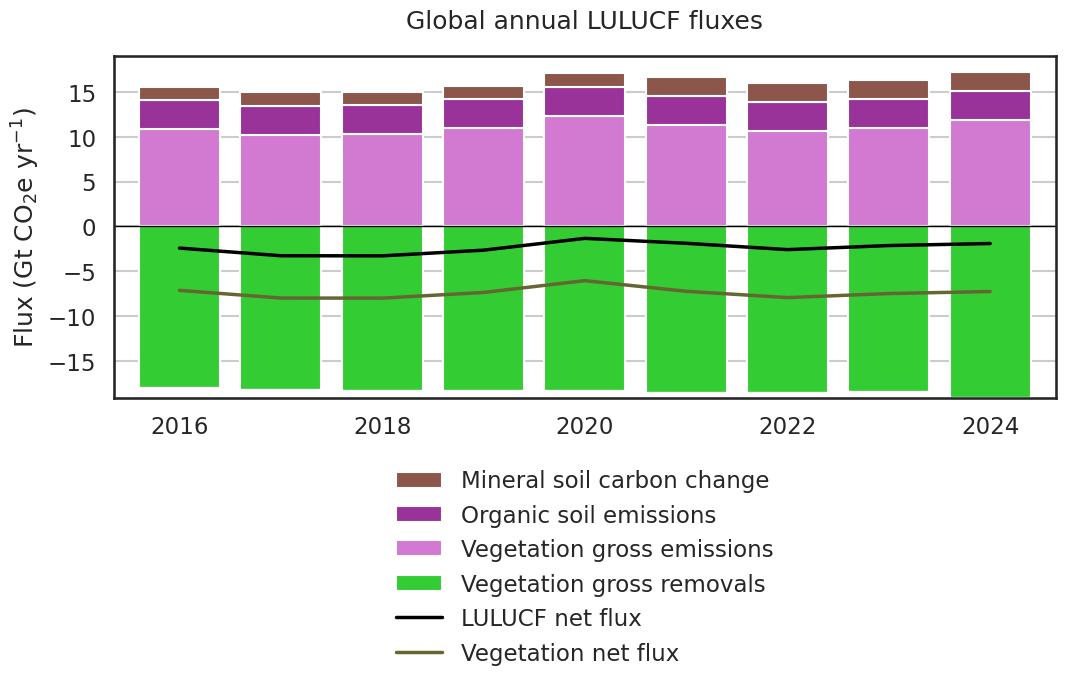

In [37]:
### Global LULUCF components with gross as bars and net veg and LULUCF as lines (single panel)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c6d457-96b4-8328-9fca-ff50f8273233

df_fig = LULUCF_outputs_dropped.copy()

## Various lists and dictionaries needed to create the figure

# Drop unwanted vegetation-only emissions layers
layers_to_drop = [
    f"veg_{cn.gross_emis_all_C_pools_CO2_only_pattern}",
    f"veg_{cn.gross_emis_all_C_pools_non_CO2_only_pattern}",
]

# Net flux layers to draw as lines instead of bars
net_flux_layers = [
    f"veg_{cn.net_flux_all_C_pools_all_gases_pattern}",
    "LULUCF_net_flux__MgCO2e",
]

# Organic soil layers to combine for graphing
organic_soil_layers = [
    "organic_soil_drainage__all_gases__MgCO2e",
    "organic_soil_extraction__all_gases__MgCO2e",
    "organic_soil_fire__all_gases__MgCO2e",
]

organic_soil_combined_label = "organic_soil__all_gases__MgCO2e"

desired_bar_order = [
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2",
    "organic_soil__all_gases__MgCO2e",
    f"veg_{cn.gross_emis_all_C_pools_all_gases_pattern}",
    f"veg_{cn.gross_removals_all_C_pools_pattern}",
]

desired_line_order = [
    "LULUCF_net_flux__MgCO2e",
    f"veg_{cn.net_flux_all_C_pools_all_gases_pattern}",
]

color_map = {
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2": "#8c564b",  # brown
    "organic_soil__all_gases__MgCO2e": "#993399",                # purple
    f"veg_{cn.gross_emis_all_C_pools_all_gases_pattern}": "#d279d2",  # light purple
    f"veg_{cn.gross_removals_all_C_pools_pattern}": "#33cc33",   # green
    "LULUCF_net_flux__MgCO2e": "#000000",                        # black
    f"veg_{cn.net_flux_all_C_pools_all_gases_pattern}": "#666633",  # green
}

label_map = {
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2":
        "Mineral soil carbon change",
    "organic_soil__all_gases__MgCO2e":
        "Organic soil emissions",
    f"veg_{cn.gross_emis_all_C_pools_all_gases_pattern}":
        "Vegetation gross emissions",
    f"veg_{cn.gross_removals_all_C_pools_pattern}":
        "Vegetation gross removals",
    "LULUCF_net_flux__MgCO2e":
        "LULUCF net flux",
    f"veg_{cn.net_flux_all_C_pools_all_gases_pattern}":
        "Vegetation net flux",
}


## Creates the figure

df_fig = df_fig[~df_fig["analysis_layer"].isin(layers_to_drop)].copy()

# Combine the three organic soil layers into one label
df_fig["analysis_layer"] = df_fig["analysis_layer"].replace(
    {layer: organic_soil_combined_label for layer in organic_soil_layers}
)

# Sum by year and analysis layer
df_ts = (
    df_fig
    .groupby(["year", "analysis_layer"], as_index=False)
    .agg({"flux_Mg_CO2e_yr": "sum"})
)

# Convert to Gt CO2e/yr
df_ts["flux_Gt_CO2e_yr"] = df_ts["flux_Mg_CO2e_yr"] / 1e9

# Pivot to wide form
df_wide = (
    df_ts
    .pivot(index="year", columns="analysis_layer", values="flux_Gt_CO2e_yr")
    .fillna(0)
)

# Apply ordering (keep only columns that exist)
bar_cols = [c for c in desired_bar_order if c in df_wide.columns]
line_cols = [c for c in desired_line_order if c in df_wide.columns]

df_bars = df_wide[bar_cols]
df_lines = df_wide[line_cols]

# Reverse bar order for plotting (top to bottom)
df_bars = df_bars[bar_cols[::-1]]

# Split positive and negative bars so they stack correctly around zero
df_pos = df_bars.clip(lower=0)
df_neg = df_bars.clip(upper=0)

fig, ax = plt.subplots(figsize=(11, 8))

# Positive stacked bars
df_pos.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8,
    color=[color_map[c] for c in df_pos.columns]
)

# Negative stacked bars
df_neg.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8,
    legend=False,
    color=[color_map[c] for c in df_neg.columns]
)

# Lines
x = np.arange(len(df_wide.index))
for col in line_cols:
    ax.plot(
        x,
        df_lines[col].values,
        linewidth=2.5,
        label=col,
        color=color_map.get(col, "black"),
        zorder=5
    )

# Formatting
ax.axhline(0, color="black", linewidth=1)
ax.grid(visible=True, axis="y")
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(MultipleLocator(5))

ax.set_xlabel(None)
ax.set_ylabel("Flux (Gt CO$_2$e yr$^{-1}$)")
ax.set_title("Global annual LULUCF fluxes", pad=20)

ax.set_xticks(x[::2])
ax.set_xticklabels(df_wide.index.astype(int)[::2], rotation=0)

# Build legend in desired order
handles, labels = ax.get_legend_handles_labels()
label_to_handle = dict(zip(labels, handles))

ordered_labels = (
    desired_bar_order +
    desired_line_order
)

ordered_labels = [l for l in ordered_labels if l in label_to_handle]

# Map labels to readable names
pretty_labels = [label_map.get(l, l) for l in ordered_labels]

ax.legend(
    [label_to_handle[l] for l in ordered_labels],
    pretty_labels,
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=1,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_global_timeseries_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

# df_wide

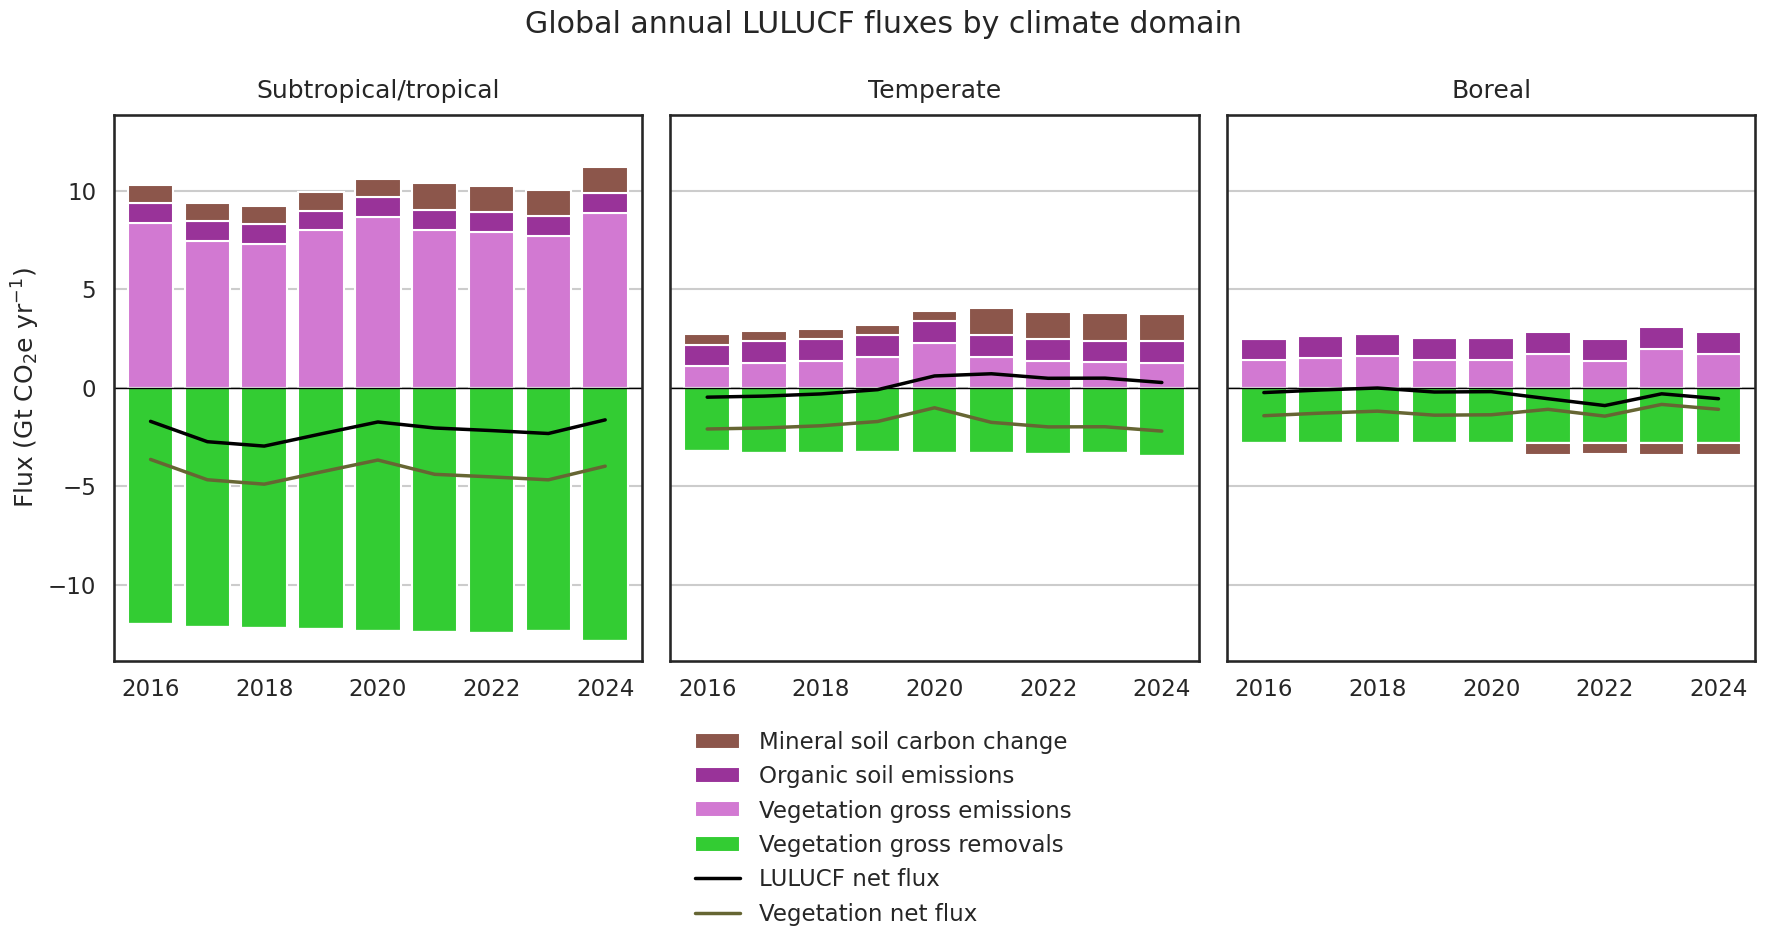

Table for Boreal (to compare against Excel spreadsheet):


analysis_layer,LULUCF_net_flux__MgCO2e,SOC_change__mineral_soil_extent__0-30cm_MgCO2,organic_soil__all_gases__MgCO2e,veg_gross_emissions__all_C_pools__all_gases__MgCO2e,veg_gross_removals__all_C_pools__MgCO2,veg_net_flux__all_C_pools__all_gases__MgCO2e
year,,,,,,
2016,-0.244276,0.064612,1.110221,1.384353,-2.803463,-1.419109
2017,-0.113089,0.064612,1.110221,1.514037,-2.801968,-1.287922
2018,-0.013177,0.064612,1.110221,1.629522,-2.817534,-1.188011
2019,-0.216259,0.064612,1.110221,1.398881,-2.789975,-1.391092
2020,-0.196913,0.064612,1.110221,1.415236,-2.786984,-1.371747
2021,-0.556773,-0.572266,1.110221,1.721854,-2.816585,-1.094727
2022,-0.903674,-0.572266,1.110221,1.339534,-2.781166,-1.441628
2023,-0.307722,-0.572266,1.110221,1.977998,-2.823687,-0.845677
2024,-0.556343,-0.572266,1.110221,1.724613,-2.819026,-1.094298


In [38]:
### Global LULUCF components with gross as bars and net veg and LULUCF as lines, panel by climate domain (three panels)
### Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69c6d457-96b4-8328-9fca-ff50f8273233

df_fig = LULUCF_outputs_dropped.copy()

## Various lists and dictionaries needed to create the figure

# Drop unwanted vegetation-only emissions layers
layers_to_drop = [
    f"veg_{cn.gross_emis_all_C_pools_CO2_only_pattern}",
    f"veg_{cn.gross_emis_all_C_pools_non_CO2_only_pattern}",
]

# Net flux layers to draw as lines instead of bars
net_flux_layers = [
    f"veg_{cn.net_flux_all_C_pools_all_gases_pattern}",
    "LULUCF_net_flux__MgCO2e",
]

# Organic soil layers to combine for graphing
organic_soil_layers = [
    "organic_soil_drainage__all_gases__MgCO2e",
    "organic_soil_extraction__all_gases__MgCO2e",
    "organic_soil_fire__all_gases__MgCO2e",
]

organic_soil_combined_label = "organic_soil__all_gases__MgCO2e"

desired_bar_order = [
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2",
    "organic_soil__all_gases__MgCO2e",
    f"veg_{cn.gross_emis_all_C_pools_all_gases_pattern}",
    f"veg_{cn.gross_removals_all_C_pools_pattern}",
]

desired_line_order = [
    "LULUCF_net_flux__MgCO2e",
    f"veg_{cn.net_flux_all_C_pools_all_gases_pattern}",
]

color_map = {
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2": "#8c564b",  # brown
    "organic_soil__all_gases__MgCO2e": "#993399",                # purple
    f"veg_{cn.gross_emis_all_C_pools_all_gases_pattern}": "#d279d2",  # light purple
    f"veg_{cn.gross_removals_all_C_pools_pattern}": "#33cc33",   # green
    "LULUCF_net_flux__MgCO2e": "#000000",                        # black
    f"veg_{cn.net_flux_all_C_pools_all_gases_pattern}": "#666633",  # green
}

label_map = {
    "SOC_change__mineral_soil_extent__0-30cm_MgCO2":
        "Mineral soil carbon change",
    "organic_soil__all_gases__MgCO2e":
        "Organic soil emissions",
    f"veg_{cn.gross_emis_all_C_pools_all_gases_pattern}":
        "Vegetation gross emissions",
    f"veg_{cn.gross_removals_all_C_pools_pattern}":
        "Vegetation gross removals",
    "LULUCF_net_flux__MgCO2e":
        "LULUCF net flux",
    f"veg_{cn.net_flux_all_C_pools_all_gases_pattern}":
        "Vegetation net flux",
}

domain_order = [
    "Subtropical/tropical",
    "Temperate",
    "Boreal",
]

domain_title_map = {
    "Subtropical/tropical": "Subtropical/tropical",
    "Temperate": "Temperate",
    "Boreal": "Boreal",
}


## Creates the figure

df_fig = df_fig[~df_fig["analysis_layer"].isin(layers_to_drop)].copy()

# Keep only requested climate domains
df_fig = df_fig[df_fig["climate_domain"].isin(domain_order)].copy()

# Combine the three organic soil layers into one label
df_fig["analysis_layer"] = df_fig["analysis_layer"].replace(
    {layer: organic_soil_combined_label for layer in organic_soil_layers}
)

# Sum by climate domain, year, and analysis layer
df_ts = (
    df_fig
    .groupby(["climate_domain", "year", "analysis_layer"], as_index=False)
    .agg({"flux_Mg_CO2e_yr": "sum"})
)

# Convert to Gt CO2e/yr
df_ts["flux_Gt_CO2e_yr"] = df_ts["flux_Mg_CO2e_yr"] / 1e9

# Compute shared y-limits across all panels
all_panel_values = []

for domain in domain_order:
    df_domain = df_ts[df_ts["climate_domain"] == domain]

    if df_domain.empty:
        continue

    df_wide = (
        df_domain
        .pivot(index="year", columns="analysis_layer", values="flux_Gt_CO2e_yr")
        .fillna(0)
    )

    bar_cols = [c for c in desired_bar_order if c in df_wide.columns]
    line_cols = [c for c in desired_line_order if c in df_wide.columns]

    if bar_cols:
        df_bars = df_wide[bar_cols]
        all_panel_values.extend(df_bars.to_numpy().ravel())

    if line_cols:
        df_lines = df_wide[line_cols]
        all_panel_values.extend(df_lines.to_numpy().ravel())

y_abs_max = max(abs(np.nanmin(all_panel_values)), abs(np.nanmax(all_panel_values)))
y_pad = y_abs_max * 0.08
ymin, ymax = -y_abs_max - y_pad, y_abs_max + y_pad


## Plot

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

legend_handles = None
legend_labels = None

for ax, domain in zip(axes, domain_order):
    df_domain = df_ts[df_ts["climate_domain"] == domain]

    if df_domain.empty:
        ax.set_visible(False)
        continue

    df_wide = (
        df_domain
        .pivot(index="year", columns="analysis_layer", values="flux_Gt_CO2e_yr")
        .fillna(0)
    )

    # Apply ordering
    bar_cols = [c for c in desired_bar_order if c in df_wide.columns]
    line_cols = [c for c in desired_line_order if c in df_wide.columns]

    df_bars = df_wide[bar_cols]
    df_lines = df_wide[line_cols]

    # Reverse for plotting so desired_bar_order reads top-to-bottom in legend
    df_bars = df_bars[bar_cols[::-1]]

    # Split positive and negative bars
    df_pos = df_bars.clip(lower=0)
    df_neg = df_bars.clip(upper=0)

    # Plot bars
    df_pos.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.8,
        legend=False,
        color=[color_map[c] for c in df_pos.columns]
    )

    df_neg.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.8,
        legend=False,
        color=[color_map[c] for c in df_neg.columns]
    )

    # Plot lines
    x = np.arange(len(df_wide.index))
    for col in line_cols:
        ax.plot(
            x,
            df_lines[col].values,
            linewidth=2.5,
            label=col,
            color=color_map.get(col, "black"),
            zorder=5
        )

    # Formatting
    ax.axhline(0, color="black", linewidth=1)
    ax.set_axisbelow(True)
    ax.grid(visible=True, axis="y")
    ax.set_ylim(ymin, ymax)

    ax.set_title(domain_title_map.get(domain, domain), pad=12)
    ax.set_xlabel(None)

    ax.set_xticks(x[::2])
    ax.set_xticklabels(df_wide.index.astype(int)[::2], rotation=0)

    if ax is axes[0]:
        ax.set_ylabel("Flux (Gt CO$_2$e yr$^{-1}$)")
    else:
        ax.set_ylabel(None)

    # Save handles once for shared legend
    if legend_handles is None:
        handles, labels = ax.get_legend_handles_labels()
        label_to_handle = dict(zip(labels, handles))
        ordered_labels = [l for l in (desired_bar_order + desired_line_order) if l in label_to_handle]
        legend_handles = [label_to_handle[l] for l in ordered_labels]
        legend_labels = [label_map.get(l, l) for l in ordered_labels]

# Shared title
fig.suptitle("Global annual LULUCF fluxes by climate domain", y=0.98)

# Shared legend below figure
fig.legend(
    legend_handles,
    legend_labels,
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=1,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.05)  # To reduce space between graphs and legend. Smaller value is smaller gap. 
# plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_climate_domain_timeseries_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()
print(f"Table for {domain} (to compare against Excel spreadsheet):")
df_wide

In [41]:
### Summary LULUCF table, with tall vegetation split by land cover change/disturbance type
### https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69cd271d-3714-8325-b311-2ccf7a07e632

df = LULUCF_summary_table.copy()

# -------------------------
# 1. Classify gas for each row
# -------------------------
def get_gas(layer):
    layer = str(layer)

    if "__CH4__" in layer:
        return "CH4_Mg_CO2e_yr"
    elif "__N2O__" in layer:
        return "N2O_Mg_CO2e_yr"
    elif "CO2_only" in layer or "mineral_soil" in layer:
        return "CO2_Mg_CO2e_yr"
    elif "all_gases" in layer:
        return "All gases_Mg_CO2e_yr"
    else:
        return None

df["gas"] = df["analysis_layer"].apply(get_gas)
df

# -------------------------
# 2. Split vegetation vs soil because they need to be handled separately
# -------------------------
veg = df[df["LULUCF_component"] == "vegetation"].copy()
soil = df[df["LULUCF_component"] != "vegetation"].copy()

# -------------------------
# 3. Vegetation: pivot WITHOUT analysis_layer in the index.
#    This is what consolidates CO2/CH4/N2O onto one row.
# -------------------------
veg_wide = (
    veg.pivot_table(
        index=[
            "land_state_broad_class",
            "land_state_detailed_class",
            "tall_veg_type",
            "LULUCF_component",
        ],
        columns="gas",
        values="flux_Mg_CO2e_yr",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)
veg_wide.columns.name = None  # Drops gas from top left of table (label for column index)

# Populates columns with 0 if they don't exist
for col in ["CO2_Mg_CO2e_yr", "CH4_Mg_CO2e_yr", "N2O_Mg_CO2e_yr", "All gases_Mg_CO2e_yr"]:
    if col not in veg_wide.columns:
        veg_wide[col] = 0

# Create vegetation total for all gases if there isn't already a total for all gases
veg_wide["All gases_Mg_CO2e_yr"] = np.where(
    veg_wide["All gases_Mg_CO2e_yr"].notna() & (veg_wide["All gases_Mg_CO2e_yr"] != 0),
    veg_wide["All gases_Mg_CO2e_yr"],
    veg_wide["CO2_Mg_CO2e_yr"] + veg_wide["CH4_Mg_CO2e_yr"] + veg_wide["N2O_Mg_CO2e_yr"]
)

# Rename analysis layer for consolidated vegetation rows (because it's no longer gas-specific)
veg_wide["analysis_layer"] = "veg_net_flux__MgCO2e"

# Reorder columns
veg_wide = veg_wide[
    [
        "analysis_layer",
        "land_state_broad_class",
        "land_state_detailed_class",
        "tall_veg_type",
        "LULUCF_component",
        "CO2_Mg_CO2e_yr",
        "CH4_Mg_CO2e_yr",
        "N2O_Mg_CO2e_yr",
        "All gases_Mg_CO2e_yr",
    ]
]
# veg_wide

# -------------------------
# 4. Soil: keep rows as all-gases-only. 
#    Don't use vegetation-specific contextual layers. 
# -------------------------
soil_wide = (
    soil.pivot_table(
        index=[
            "analysis_layer",
            "LULUCF_component",
        ],
        columns="gas",
        values="flux_Mg_CO2e_yr",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)
soil_wide.columns.name = None  # Drops gas from top left of table (label for column index)

# Add vegetation columns back to soil table so the tables can be combined
soil_wide["land_state_broad_class"] = "NA"
soil_wide["land_state_detailed_class"] = "NA"
soil_wide["tall_veg_type"] = "NA"

# Populates columns with 0 if they don't exist
for col in ["CO2_Mg_CO2e_yr", "CH4_Mg_CO2e_yr", "N2O_Mg_CO2e_yr", "All gases_Mg_CO2e_yr"]:
    if col not in soil_wide.columns:
        soil_wide[col] = 0

# Create soil total for all gases if there isn't already a total for all gases
soil_wide["All gases_Mg_CO2e_yr"] = np.where(
    soil_wide["All gases_Mg_CO2e_yr"].notna() & (soil_wide["All gases_Mg_CO2e_yr"] != 0),
    soil_wide["All gases_Mg_CO2e_yr"],
    soil_wide["CO2_Mg_CO2e_yr"] + soil_wide["CH4_Mg_CO2e_yr"] + soil_wide["N2O_Mg_CO2e_yr"]
)

# Same calumn order for soil columns
soil_wide = soil_wide[
    [
        "analysis_layer",
        "land_state_broad_class",
        "land_state_detailed_class",
        "tall_veg_type",
        "LULUCF_component",
        "CO2_Mg_CO2e_yr",
        "CH4_Mg_CO2e_yr",
        "N2O_Mg_CO2e_yr",
        "All gases_Mg_CO2e_yr",
    ]
]
# soil_wide

# -------------------------
# 5. Combine veg and soil
# -------------------------
df_wide = pd.concat([veg_wide, soil_wide], ignore_index=True)
df_wide

# -------------------------
# 6. Creates table entries 
# -------------------------

gas_cols = ["CO2_Mg_CO2e_yr", "CH4_Mg_CO2e_yr", "N2O_Mg_CO2e_yr", "All gases_Mg_CO2e_yr"]

def get_sum(df, mask, section, subsection, category):
    vals = df.loc[mask, gas_cols].sum().round(0)

    return {
        "Section": section,
        "Subsection": subsection,
        "Category": category,
        **vals.to_dict()
    }

rows = []

# -------------------------
# Vegetation — Tall vegetation
# -------------------------
rows.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (df_wide["land_state_detailed_class"] == "tree_gain"),
    "Vegetation", "Tall vegetation", "New tree cover"
))
rows.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (df_wide["land_state_detailed_class"] == "tree_tree_undisturbed"),
    "Vegetation", "Tall vegetation", "Undisturbed tree cover"
))
rows.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (
        (df_wide["land_state_detailed_class"] == "tree_tree_disturbed") |
        (df_wide["land_state_detailed_class"] == "tree_tree_disturbed_fire_only")
    ),
    "Vegetation", "Tall vegetation", "Partially disturbed tree cover"
))
rows.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (df_wide["land_state_detailed_class"] == "tree_loss"),
    "Vegetation", "Tall vegetation", "Tree cover loss"
))
# Total tall vegetation
rows.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree"),
    "Vegetation", "Tall vegetation", "Total"
))

# -------------------------
# Vegetation — Non-tall
# -------------------------
rows.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["tall_veg_type"] == "non_tall_vegetation"),
    "Vegetation", "Non-tall vegetation", "All classes"
))

# -------------------------
# Vegetation — Total
# -------------------------
rows.append(get_sum(
    df_wide,
    df_wide["LULUCF_component"] == "vegetation",
    "Vegetation", "All vegetation", "Total"
))

# -------------------------
# Soil — Organic
# -------------------------
rows.append(get_sum(
    df_wide,
    df_wide["analysis_layer"].str.contains("organic_soil_fire"),
    "Soil", "Organic soil", "Fire"
))

rows.append(get_sum(
    df_wide,
    df_wide["analysis_layer"].str.contains("organic_soil_extraction"),
    "Soil", "Organic soil", "Extraction"
))

rows.append(get_sum(
    df_wide,
    df_wide["analysis_layer"].str.contains("organic_soil_drainage"),
    "Soil", "Organic soil", "Drainage"
))

# Total organic soil
rows.append(get_sum(
    df_wide,
    df_wide["LULUCF_component"] == "organic_soil",
    "Soil", "Organic soil", "Total"
))

# -------------------------
# Soil — Mineral
# -------------------------
rows.append(get_sum(
    df_wide,
    df_wide["LULUCF_component"] == "mineral_soil",
    "Soil", "Mineral soil", "All classes"
))

# -------------------------
# Soil — Total
# -------------------------
rows.append(get_sum(
    df_wide,
    df_wide["LULUCF_component"].isin(["organic_soil", "mineral_soil"]),
    "Soil", "All soil", "Total"
))

# -------------------------
# LULUCF — Total
# -------------------------
rows.append(get_sum(
    df_wide,
    pd.Series([True] * len(df_wide)),
    "LULUCF", "All components", "Total"
))

# -------------------------
# 6. Creates final table 
# -------------------------

summary_by_land_cover = pd.DataFrame(rows)

# Convert Mg → Gt
summary_by_land_cover[gas_cols] = summary_by_land_cover[gas_cols] / 1e9

# Rename column units
summary_by_land_cover = summary_by_land_cover.rename(columns={
    "CO2_Mg_CO2e_yr": "CO2_Gt_CO2e_yr",
    "CH4_Mg_CO2e_yr": "CH4_Gt_CO2e_yr",
    "N2O_Mg_CO2e_yr": "N2O_Gt_CO2e_yr",
    "All gases_Mg_CO2e_yr": "All_gases_Gt_CO2e_yr",
})

summary_by_land_cover = summary_by_land_cover.round(3).style.hide(axis="index")
summary_by_land_cover

Section,Subsection,Category,CO2_Gt_CO2e_yr,CH4_Gt_CO2e_yr,N2O_Gt_CO2e_yr,All_gases_Gt_CO2e_yr
Vegetation,Tall vegetation,New tree cover,-0.231000,0.000000,0.000000,-0.231000
Vegetation,Tall vegetation,Undisturbed tree cover,-17.030000,0.000000,0.000000,-17.030000
Vegetation,Tall vegetation,Partially disturbed tree cover,2.781000,0.172000,0.054000,3.007000
Vegetation,Tall vegetation,Tree cover loss,6.747000,0.040000,0.017000,6.804000
Vegetation,Tall vegetation,Total,-7.734000,0.213000,0.070000,-7.451000
Vegetation,Non-tall vegetation,All classes,-0.024000,0.042000,0.030000,0.048000
Vegetation,All vegetation,Total,-7.758000,0.255000,0.100000,-7.403000
Soil,Organic soil,Fire,0.000000,0.000000,0.000000,1.043000
Soil,Organic soil,Extraction,0.000000,0.000000,0.000000,0.031000
Soil,Organic soil,Drainage,0.000000,0.000000,0.000000,2.134000


In [ ]:
# LULUCF waterfall diagram
# Made with Claude

# ── 0. Pull underlying DataFrame from the Styler ────────────────────────────
df_wf = summary_by_land_cover.data.copy()

# ── 1. Select detail rows + LULUCF total as closing bar ─────────────────────
detail_mask = (
    ((df_wf["Subsection"] == "Tall vegetation")   & (df_wf["Category"] != "Total")) |
    ( df_wf["Subsection"] == "Non-tall vegetation")                                  |
    ((df_wf["Subsection"] == "Organic soil")       & (df_wf["Category"] != "Total")) |
    ( df_wf["Subsection"] == "Mineral soil")                                         |
    ((df_wf["Section"]    == "LULUCF")             & (df_wf["Category"] == "Total"))
)
wf = df_wf[detail_mask][["Section", "Subsection", "Category", "All_gases_Gt_CO2e_yr"]].reset_index(drop=True)
wf["is_total"] = (wf["Section"] == "LULUCF") & (wf["Category"] == "Total")

# ── 2. Waterfall geometry ────────────────────────────────────────────────────
vals    = wf["All_gases_Gt_CO2e_yr"].values.astype(float)
bottoms = np.zeros(len(vals))
running = 0.0

for i in range(len(vals)):
    if wf["is_total"].iloc[i]:
        bottoms[i] = 0.0          
    else:
        bottoms[i] = running
        running   += vals[i]

# ── 3. Colors ────────────────────────────────────────────────────────────────
SINK   = "#33cc33"
SOURCE = "#d279d2"
TOTAL  = "#616161"

colors = [
    TOTAL  if wf["is_total"].iloc[i] else
    SINK   if vals[i] < 0            else
    SOURCE
    for i in range(len(vals))
]

# ── 4. Tick labels ───────────────────────────────────────────────────────────
def make_label(row):
    if row["is_total"]:
        return "LULUCF\nTotal"
    cat, sub = row["Category"], row["Subsection"]
    short = {
        "Undisturbed tree cover (including fires)": "Undisturbed\ntree cover",
        "Partially disturbed tree cover":           "Partially\ndisturbed\ntree cover",
        "New tree cover":                           "New\ntree cover",
        "Tree cover loss":                          "Tree cover\nloss",
        "Fire":                                     "Organic soil\nFire",
        "Extraction":                               "Organic soil\nExtraction",
        "Drainage":                                 "Organic soil\nDrainage",
    }
    # Handle "All classes" by subsection
    if cat == "All classes":
        if sub == "Non-tall vegetation":
            return "Short veg. &\ncropland"
        else:
            return sub  # e.g. "Mineral soil"
    return short.get(cat, cat)

labels = [make_label(row) for _, row in wf.iterrows()]

# ── 5. Section midpoints for top axis ───────────────────────────────────────
sections = wf["Section"].values
section_groups = {}
for i, s in enumerate(sections):
    section_groups.setdefault(s, []).append(i)

# ── 6. Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

bar_bottoms = np.where(vals < 0, bottoms + vals, bottoms)
bar_heights = np.abs(vals)

bars = ax.bar(
    range(len(vals)),
    bar_heights,
    bottom=bar_bottoms,
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    width=0.65,
)

ax.grid(visible=True, axis="y")
ax.set_axisbelow(True)

# Dashed horizontal connectors between consecutive flow bars
for i in range(len(vals) - 1):
    if not wf["is_total"].iloc[i] and not wf["is_total"].iloc[i + 1]:
        y = bottoms[i] + vals[i]
        ax.plot([i + 0.33, i + 0.67], [y, y],
                color="grey", linewidth=0.8, linestyle="--", alpha=0.6)

# FIX 3+4: 3 sig figs; small bars labelled outside in dark text
SMALL_BAR = 0.6   # Gt threshold below which label goes outside

for i, (bar, val) in enumerate(zip(bars, vals)):
    label_text = f"{val:+.2g}"
    if bar.get_height() < SMALL_BAR:
        # Place above positive bars, below negative bars
        if val >= 0:
            y_pos, va = bar.get_y() + bar.get_height() + 0.15, "bottom"
        else:
            y_pos, va = bar.get_y() - 0.15, "top"
        ax.text(bar.get_x() + bar.get_width() / 2, y_pos, label_text,
                ha="center", va=va, fontsize=7.5, color="black", fontweight="bold")
    else:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2, label_text,
                ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")

# Zero reference line
ax.axhline(0, color="black", linewidth=0.9)

# Solid vertical section dividers
for i in range(1, len(sections)):
    if sections[i] != sections[i - 1]:
        ax.axvline(i - 0.5, color="#555555", linewidth=1.2, linestyle="-", alpha=0.35)

# Bottom axis
ax.set_xticks(range(len(vals)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.tick_params(axis="x", labelsize=10)
ax.set_ylabel("Gt CO₂e yr⁻¹")
ax.set_title("LULUCF GHG flux components (all GHGs, average for 2016-2024)", pad=20)

# Top axis: section labels
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([np.mean(idxs) for idxs in section_groups.values()])
ax2.set_xticklabels(list(section_groups.keys()), fontweight="bold")
ax2.tick_params(length=0)

# Legend
ax.legend(
    handles=[
        mpatches.Patch(color=SINK,   label="Sink (−)"),
        mpatches.Patch(color=SOURCE, label="Source (+)"),
        mpatches.Patch(color=TOTAL,  label="Net sink"),
    ],
    loc="lower right", fontsize=9
)

plt.tight_layout()
plt.savefig(f'{LULUCF_zonal_stats_folder}/LULUCF_global_waterfall_{today}.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### Summary LULUCF table, with tall vegetation split by tall veg type
### https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c/c/69cd271d-3714-8325-b311-2ccf7a07e632'

# Continued from above

rows_tall_veg_type = []

# -------------------------
# Vegetation — Tall vegetation
# -------------------------
rows_tall_veg_type.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (df_wide["tall_veg_type"] == "mangrove"),
    "Vegetation", "Tall vegetation", "Mangrove"
))
rows_tall_veg_type.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (df_wide["tall_veg_type"] == "natural_tree_cover"),
    "Vegetation", "Tall vegetation", "Natural tree cover"
))
rows_tall_veg_type.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (df_wide["tall_veg_type"] == "non_oil_palm_planted_trees"),
    "Vegetation", "Tall vegetation", "Non-oil palm planted trees"
))
rows_tall_veg_type.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (df_wide["tall_veg_type"] == "oil_palm"),
    "Vegetation", "Tall vegetation", "Oil palm"
))
rows_tall_veg_type.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree") &
    (df_wide["tall_veg_type"] == "trees_in_other_land_covers"),
    "Vegetation", "Tall vegetation", "Trees in other land covers"
))
# Total tall vegetation
rows_tall_veg_type.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["land_state_broad_class"] == "tree"),
    "Vegetation", "Tall vegetation", "Total"
))

# -------------------------
# Vegetation — Non-tall
# -------------------------
rows_tall_veg_type.append(get_sum(
    df_wide,
    (df_wide["LULUCF_component"] == "vegetation") &
    (df_wide["tall_veg_type"] == "non_tall_vegetation"),
    "Vegetation", "Non-tall vegetation", "All classes"
))

# -------------------------
# Vegetation — Total
# -------------------------
rows_tall_veg_type.append(get_sum(
    df_wide,
    df_wide["LULUCF_component"] == "vegetation",
    "Vegetation", "All vegetation", "Total"
))

# -------------------------
# Soil — Organic
# -------------------------
rows_tall_veg_type.append(get_sum(
    df_wide,
    df_wide["analysis_layer"].str.contains("organic_soil_fire"),
    "Soil", "Organic soil", "Fire"
))

rows_tall_veg_type.append(get_sum(
    df_wide,
    df_wide["analysis_layer"].str.contains("organic_soil_extraction"),
    "Soil", "Organic soil", "Extraction"
))

rows_tall_veg_type.append(get_sum(
    df_wide,
    df_wide["analysis_layer"].str.contains("organic_soil_drainage"),
    "Soil", "Organic soil", "Drainage"
))

# Total organic soil
rows_tall_veg_type.append(get_sum(
    df_wide,
    df_wide["LULUCF_component"] == "organic_soil",
    "Soil", "Organic soil", "Total"
))

# -------------------------
# Soil — Mineral
# -------------------------
rows_tall_veg_type.append(get_sum(
    df_wide,
    df_wide["LULUCF_component"] == "mineral_soil",
    "Soil", "Mineral soil", "All classes"
))

# -------------------------
# Soil — Total
# -------------------------
rows_tall_veg_type.append(get_sum(
    df_wide,
    df_wide["LULUCF_component"].isin(["organic_soil", "mineral_soil"]),
    "Soil", "All soil", "Total"
))

# -------------------------
# LULUCF — Total
# -------------------------
rows_tall_veg_type.append(get_sum(
    df_wide,
    pd.Series([True] * len(df_wide)),
    "LULUCF", "All components", "Total"
))

# -------------------------
# 6. Creates final table 
# -------------------------

summary_by_veg_type = pd.DataFrame(rows_tall_veg_type)

# Convert Mg → Gt
summary_by_veg_type[gas_cols] = summary_by_veg_type[gas_cols] / 1e9

# Rename column units
summary_by_veg_type = summary_by_veg_type.rename(columns={
    "CO2_Mg_CO2e_yr": "CO2_Gt_CO2e_yr",
    "CH4_Mg_CO2e_yr": "CH4_Gt_CO2e_yr",
    "N2O_Mg_CO2e_yr": "N2O_Gt_CO2e_yr",
    "All gases_Mg_CO2e_yr": "All_gases_Gt_CO2e_yr",
})

summary_by_veg_type = summary_by_veg_type.round(3).style.hide(axis="index")
summary_by_veg_type